***Indexing Laue pattern of several images using multiprocessing***

on jupyter-slurm.esrf.fr (jupyterlab or jupyterhub)

or

locally on desktop computer (with some cpus) and with access to the LaueTools environment or folder

or lbm32gpu1 (@ESRF)

**This Notebook is a part of the LaueTools Package** 
Author: J.-S. Micha

Last Revision:   January 2026

tested with python 3.12  on jupyterlab and jupyter hub, jupyter-notebook

**Objectives**

- 1 image

-- Index from scratch and Refine Strain

-- Check orientation and Refine Strain (followed or not by indexing from scratch), use previous results (1 or n orientation matrix)

- N images

-- Use previous results (DB orientation matrix, propagation)


The main goal of indexing is to:

- identify hkl Miller indices of Laue spots
- identify phase material of Laue spots (grain)

As a results:

- .fit files are generated (all indexed spots properties list )
- ####_g0.fit, ####_g1.fit, ... generated (indexed spots properties list per grain)


# SET runtime jupyterlab or not

In [7]:
JUPYTER_LAB = True # jupyter lab (at ESRF)
JUPYTER_HUB = False # jupyter hub or notebook
JUPYTER_VSCODE = False #  jupyter on vscode

# IMPORTS

In [8]:
if not JUPYTER_LAB: # jupyterhub
    %matplotlib notebook  
else:
    %matplotlib widget 

import time,copy,os
from pathlib import Path

# Third party modules
import matplotlib as mpl     # graphs and plots
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

from tqdm import tqdm, tqdm_notebook
import multiprocessing
from multiprocessing import active_children, cpu_count
os.environ["OMP_NUM_THREADS"] = "1"   # 1 or 2 or 4

nbmaxcpus = multiprocessing.cpu_count()
print(f'nb of cpus available: {nbmaxcpus}')

import itertools
import warnings
#warnings.filterwarnings('always')

nb of cpus available: 64


In [9]:
#OR use your own lauetools.
# Setting absolute path to LaueTools Modules if Lauetools has not been installed with pip
if 1:
    import sys
    # for slurm machines
    # sys.path.insert(0,'/home/esrf/micha/lauetools_devNotebooks/lauetools')
    # # for lbm32gpu1 machine (test temp)
    #sys.path.insert(0,'/data/bm32/inhouse/STAFF/JSM/lauetools_devNotebooks/lauetools')

    sys.path.insert(0,'/data/bm32/inhouse/lauetoolsenv2/lib/python3.12/site-packages')
    
    import LaueTools as LT
    print('code from', LT.__file__)

code from /data/bm32/inhouse/lauetoolsenv2/lib/python3.12/site-packages/LaueTools/__init__.py


In [10]:
# LaueTools modules
import LaueTools.readmccd as RMCCD
#import LaueTools.LaueGeometry as F2TC
import LaueTools.indexingSpotsSet as ISS
import LaueTools.indexingAnglesLUT as IAL
import LaueTools.IOLaueTools as IOLT
import LaueTools.generaltools as GT
import LaueTools.dict_LaueTools as DictLT

# SET user scan measurements inputs or dataset

folder of .cor files, 2D map dimensions, Laue detector type ...

In [11]:
# use default library of materials
mymaterials = None

In [12]:
# select your dataset example from experiment Id
#DATASET_EXAMPLE = 'Al/Al2Cu'    Akamatsu et al
expId = '322812'

#DATASET_EXAMPLE = 'Cr/Zr'  Ribart et al
expId = 'a321216'

#expId = 'blc15488'  not ready

#DATASET_EXAMPLE = 'Zn'  Zheng et al
#expId = 'ma6034'

#DATASET_EXAMPLE = 'ZrO2'  Guinebretiere et al
#expId = 'a321206'

expId = 'utr20'

## Al  utr20

In [15]:
# A321216
#DATASET_EXAMPLE == 'Zr':
if expId == 'utr20':
    DATASET_EXAMPLE = 'Al'
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/visitor/utr20/bm32/20260310'

    # subfolder where images .h5are
    subfolderscandata = '/PROCESSED_DATA//RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001'

    mainprocessed_data = Path(maindatafolder+'//'+'PROCESSED_DATA')
    
    
    # Create the folder if it doesn't exist
    mainprocessed_data.mkdir(parents=True, exist_ok=True)

    prefixfilename= 'eiger4m_'
    suffix='.h5'
    CCDLabel = 'EIGER_4MCdTe'
    sizeofzeropadding = 4
    
    
    
    # calibration parameters file
    detfile = Path('/data/visitor/utr20/bm32/20260310/RAW_DATA/Alafternoon/Alafternoon_Ge/scan0001/calib_Ge_001_EIGER4M.det')
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    mapdims = (51,51)   # fast   , slow     here yech , xech
    invmapdims = mapdims[1], mapdims[0]
    
    HDF5_LOGFILE_EXISTS = True
    if HDF5_LOGFILE_EXISTS:
        pathHDF5 = os.path.join(maindatafolder,'RAW_DATA','utr20_bm32.h5')


    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    
    #mainprocessed_data = '/data/visitor/a321216/bm32/20251008/PROCESSED_DATA'
    #studysubfolder = subfolderscandata
    #workdir = str(Path(mainprocessed_data+'//'+studysubfolder))

    #datfilefolder = str(Path(mainprocessed_data+'/'+subfolderscandata+'//'+'corfiles'))
    datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'corfiles'))
    corfilefolder = datfilefolder
    
    # fitfilefolder = Path(mainprocessed_data+'/'+subfolderscandata+'//'+'fitfiles_notebook')
    # for tutorials
    fitfilefolder = Path(str(mainprocessed_data)+'//'+'fitfiles')
    workdir = str(Path(mainprocessed_data))
    
    
    os.makedirs(fitfilefolder, exist_ok=True)
    #Disable if calling cor repo manually
    #corfilefolder = datfilefolder
        
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)
    print('datfilefolder', datfilefolder)

images folder:  
    =====> /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001
.fit files will be written in this folder: 
    =====> /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/fitfiles
datfilefolder /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles


## Al/Al2Cu

In [38]:
# DATASET_EXAMPLE == 'Al/Al2Cu'
if expId == '322812':
    DATASET_EXAMPLE = 'Al/Al2Cu'
    print(DictLT.dict_Materials['Al'])
    print(DictLT.dict_Materials['Al2Cu'])
    print(DictLT.dict_Materials['Al2O3'])

    #'/data/bm32/inhouse/data/laue/32-02-812/PROCESSED_DATA/corfiles/'
    #32-02-812  Akamatsu et al

    HDF5_LOGFILE_EXISTS=False
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/bm32/inhouse/data/laue/32-02-812'
    # subfolder where images .tiff are
    subfolderscandata = ''
    
    prefixfilename= 'ech28_'
    suffix='.cor'
    CCDLabel = 'sCMOS'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif
    
    # calibration parameters file
    detfile = Path(maindatafolder+'/'+'calibGe111_sCMOS_3202812_vendredi_ech44.det')
    
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    mapdims = (17,17)
    invmapdims = mapdims[1], mapdims[0]
    
    HDF5_LOGFILE_EXISTS = False
    if HDF5_LOGFILE_EXISTS:
        pathHDF5 = os.path.join(maindatafolder,'a321206_bm32.h5')
        
    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    datfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'PROCESSED_DATA'+'//'+'corfiles')
    #corfilefolder = datfilefolder
    corfilefolder = datfilefolder #Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles')
    
    fitfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'PROCESSED_DATA'+'//'+'fitfiles')
    
    os.makedirs(fitfilefolder, exist_ok=True)
    #Disable if calling cor repo manually
    #corfilefolder = datfilefolder
    
    #outputfolder = '/data/visitor/blc14894/bm32/20231007/NOBACKUP/'
    
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)

    mymaterials = None

## Zr polycrystals

In [39]:
# A321216
#DATASET_EXAMPLE == 'Zr':
if expId == 'a321216':
    DATASET_EXAMPLE = 'Zr'
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/visitor/a321216/bm32/20251008/RAW_DATA'

    # subfolder where images .tiff are
    subfolderscandata = 'ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep/scan0001'
    subfolderscandata = 'ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001'

    #mainprocessed_data = Path(maindatafolder+'//'+'PROCESSED_DATA')
    # Define the folder path starting from the home directory
    mainprocessed_data = Path(f"~/LaueTutorialsResults/Indexation_{expId}").expanduser()
    
    # Create the folder if it doesn't exist
    mainprocessed_data.mkdir(parents=True, exist_ok=True)
    
    prefixfilename= 'img_'
    suffix='.cor'
    CCDLabel = 'sCMOS_4M'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif
    
    
    # calibration parameters file
    detfile = str(Path(maindatafolder+'/'+'Ge1/Ge1_calib_std/scan0001/Ge1.det'))
    
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    mapdims = (51,61)   # fast   , slow     here yech , xech
    invmapdims = mapdims[1], mapdims[0]
    
    HDF5_LOGFILE_EXISTS = True
    if HDF5_LOGFILE_EXISTS:
        pathHDF5 = os.path.join(maindatafolder,'a321216_bm32.h5')


    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    
    #mainprocessed_data = '/data/visitor/a321216/bm32/20251008/PROCESSED_DATA'
    #studysubfolder = subfolderscandata
    #workdir = str(Path(mainprocessed_data+'//'+studysubfolder))

    #datfilefolder = str(Path(mainprocessed_data+'/'+subfolderscandata+'//'+'corfiles'))
    datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))
    corfilefolder = datfilefolder
    
    # fitfilefolder = Path(mainprocessed_data+'/'+subfolderscandata+'//'+'fitfiles_notebook')
    # for tutorials
    fitfilefolder = Path(str(mainprocessed_data)+'//'+'fitfiles')
    workdir = str(Path(mainprocessed_data))
    
    
    os.makedirs(fitfilefolder, exist_ok=True)
    #Disable if calling cor repo manually
    #corfilefolder = datfilefolder
        
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)
    print('datfilefolder', datfilefolder)

images folder:  
    =====> /data/visitor/a321216/bm32/20251008/RAW_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001
.fit files will be written in this folder: 
    =====> /home/micha/LaueTutorialsResults/Indexation_a321216/fitfiles
datfilefolder /data/visitor/a321216/bm32/20251008/RAW_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/img_CORfiles


In [40]:
# BLC15488
if expId == 'blc15488':
    DATASET_EXAMPLE = 'Zr'
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/projects/mapgrainxl/blc15488/bm32/20240601/RAW_DATA'

    # subfolder where images .tiff are
    subfolderscandata = 'ech15/ech15_map2Dexpo0p1sec/scan0001'

    prefixfilename= 'img_'
    suffix='.cor'
    CCDLabel = 'sCMOS'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif
    
    # calibration parameters file
    detfile = Path(maindatafolder+'/'+'ech15/ech15_Ge/scan0001/calibGe.det')
    
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    mapdims = (61,51)   # fast   , slow     here xech , yech
    invmapdims = mapdims[1], mapdims[0]
    
    HDF5_LOGFILE_EXISTS = True
    if HDF5_LOGFILE_EXISTS:
        pathHDF5 = os.path.join(maindatafolder,'blc15488_bm32.h5')
        
    # -----------------automatically generated folder ---------------------------------
    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    datfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'datfiles_notebook')
    #corfilefolder = datfilefolder
    corfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles')
    
    # for tutorials
    mainprocessed_data = Path(f"~/LaueTutorialsResults/Indexation_{expId}").expanduser()
    
    # Create the folder if it doesn't exist
    mainprocessed_data.mkdir(parents=True, exist_ok=True)
    workdir = str(Path(mainprocessed_data))
    
    #mainprocessed_data = '/data/projects/mapgrainxl/blc15488/bm32/20240601/PROCESSED_DATA/'
    #studysubfolder = subfolderscandata
    #/data/projects/mapgrainxl/blc15488/bm32/20240601/PROCESSED_DATA/ech15/ech15_map2Dexpo0p1sec/scan0001/
    #workdir = str(Path(mainprocessed_data+'//'+studysubfolder))
    #datfilefolder = str(Path(mainprocessed_data+'/'+subfolderscandata+'//'+'corfiles'))
    datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))
    corfilefolder = datfilefolder
    
    #fitfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'fitfiles_JSM')
    # for tutorials
    fitfilefolder = Path(str(mainprocessed_data)+'//'+'fitfiles_JSM')

    os.makedirs(fitfilefolder, exist_ok=True)
    
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)

## Zn dendrites

In [19]:
# DATASET_EXAMPLE=='Zn':
if expId == 'ma6034':
    
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/projects/zndendrites/ma6034/bm32/20240625/RAW_DATA'
    # subfolder where images .tiff are
    subfolderscandata = 'sample1_test/sample1_test_sample5-30m-new2-coarse-large/scan0001'
    
    datfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'datfiles_notebook')
    corfilefolder = datfilefolder

    #mainprocessed_data = Path(maindatafolder+'//'+'PROCESSED_DATA')
    # Define the folder path starting from the home directory
    mainprocessed_data = Path(f"~/LaueTutorialsResults/Indexation_{expId}").expanduser()
    
    # Create the folder if it doesn't exist
    mainprocessed_data.mkdir(parents=True, exist_ok=True)
    
    prefixfilename= 'img_'
    suffix='.cor'
    CCDLabel = 'sCMOS'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif
    
    # calibration parameters file
    detfile = Path(maindatafolder+'/'+'sample1_test/sample1_test_Ge_20240628/scan0001/Ge111calib_28june2024.det')
    
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor2 + 1, nbsteps motor1 + 1) = (slow motor, fast motor)
    mapdims = (41,41)
    invmapdims = mapdims[1], mapdims[0]
    
    if not Path(maindatafolder+'/'+subfolderscandata).exists():
        raise ValueError(f'The folder {Path(maindatafolder+"/"+subfolderscandata)} does not exists!')
    
    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)

    #fitfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'fitfiles_notebook')
    fitfilefolder = Path(str(mainprocessed_data)+'//'+'fitfiles_notebook')
    
    os.makedirs(fitfilefolder, exist_ok=True)
    #Disable if calling cor repo manually
    #corfilefolder = datfilefolder
    
    #outputfolder = '/data/visitor/blc14894/bm32/20231007/NOBACKUP/'
    
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)
    

### Some orientation matrices

In [20]:
# Guessed UB matrix (example)
UB_1 = np.array([[ 0.800890339,  0.111020812,  0.588618058],
       [ 0.006589284, -0.983840123,  0.176252946],
       [ 0.59871938 , -0.137579654, -0.788529267]])

UB_2 = np.array([[-0.944886962989832, -0.16481648329929 ,  0.282364299451425],
       [ 0.325288903402363, -0.401682702128187,  0.855560084566674],
       [-0.027898445634874,  0.899571897959609,  0.434481129960923]])

UB_3 = np.array([[ 0.798694755,  0.111538191,  0.591397078],
       [ 0.005701942, -0.983734667,  0.177867478],
       [ 0.601654241, -0.138824412, -0.786302534]])

UB_4 = np.array([[-0.944887005, -0.164816017,  0.282364339],
       [ 0.325288815, -0.401682583,  0.855559726],
       [-0.027898058,  0.899571114,  0.434480798]])

UB_5 = np.array([[ 0.790931358,  0.04942662 ,  0.610343974],
       [ 0.006278407, -0.99719131 ,  0.072531087],
       [ 0.611965387, -0.053681208, -0.788581226]])

UB_6 = np.array([[ 0.790951967,  0.049463864,  0.610128265],
       [ 0.006315838, -0.997021885,  0.072650861],
       [ 0.611938365, -0.053678736, -0.788500541]])

UB547 = np.array([[-0.944920932918629, -0.164116940216228,  0.28227572173489 ],
       [ 0.325197212589104, -0.401535417654801,  0.855019004360563],
       [-0.027816725726933,  0.89905990210913 ,  0.434389207372524]])

UB218 = np.array([[-0.496826852073101, -0.638273298777973, -0.588555208999875],
       [ 0.848892814668109, -0.497871277128914, -0.176531037918834],
       [-0.180000922484652, -0.587384245192303,  0.788803460478765]])

### Some orientation matrices

In [41]:
 #GOI 1 - Zr
#NB: CAUTION 
UB_Zr_1 = np.array([[-0.715649128,  0.083196626, -0.693582905],
                [ -0.274818874, -0.946425938,  0.169636022],
                [ -0.642010804,  0.310566961,  0.701280083]])

#GOI 3 - Zr
UB_Zr_3 = np.array([[ 0.448549611,  0.103010639, -0.887987377],
                    [ 0.212069947,  0.953211693,  0.217324011],
                    [ 0.868557547, -0.284717106,  0.406654304]])


# GOI - Cr = CAUTION: We were able to index a Cr grain
UB_Cr_1 = np.array([[ 0.253734688, -0.966571946, -0.036701339],
                    [ -0.151499426, -0.001523219, -0.98836153],
                    [ 0.955351885,  0.258303731, -0.148071266]])

UB_Zr_828 = np.array([[ 0.286398422302201, -0.662359423093821, -0.69545143910691 ],
                   [ 0.956705409395281,  0.235980441180103,  0.170780837853894],
                   [ 0.051855826535398, -0.712277801417387,  0.700105128281243]])

# some previous results
if expId == 'blc15488':  # ???
    UB_IMG208_Zr_G0 = np.array([[-0.112798277273925,  0.264283768936951, -0.959088148240022],
           [-0.877156117029428,  0.42783166935261 ,  0.220801693524999],
           [ 0.466630682114979,  0.865400738208747,  0.184125402405369]])
    
    UB_IMG208_Zr_G1 = np.array([[-0.562705662991257, -0.506301694554734,  0.665247385476388],
           [ 0.415142984485895,  0.528172588649008,  0.743784341650145],
           [-0.719449839503281,  0.67927978351221 , -0.090500747250987]])
    UB_IMG_205_G1 = np.array([[-0.516363540883251,  0.307665657576283, -0.797216756790789],
           [-0.601836295002085,  0.527854425116734,  0.599381003752638],
           [ 0.609026913819394,  0.793376636209741, -0.087308473127964]])
    UB_259 = np.array([[-0.557867151443495, -0.795750512160686,  0.244442422530371],
           [-0.520505141599872,  0.562076465369887,  0.641499591630919],
           [-0.646978346331528,  0.231597087677089, -0.725767034683252]])
    UB_269 = np.array([[-0.112703133160243,  0.264388221745783, -0.959196233058513],
           [-0.877117569928531,  0.427892276014889,  0.22076095328233 ],
           [ 0.466726119675911,  0.865254495936136,  0.184119910254875]])
    
    UB_275 = np.array([[-0.113180544631654,  0.263473707596578, -0.959258848306088],
           [-0.877214237188706,  0.427278082255405,  0.221286229492941],
           [ 0.466428820807118,  0.865351376268245,  0.184347402849626]])
    
    UB_277 = np.array([[-0.796892278514895, -0.418385992456327, -0.444032005207359],
           [ 0.125405032242812, -0.822248179289292,  0.554246490939731],
           [-0.590966116554159,  0.379689719474418,  0.705497427650818]])
    
    UB_276 = np.array([[-0.099087799344665,  0.866739015441018, -0.492689495609321],
           [-0.964786607680811,  0.037622194858899,  0.261014947015799],
           [ 0.243513004295334,  0.498923595942045,  0.831496960311785]])  # 96 peaks!

    GT.getRotationAngleFrom2Matrices(UB_Zr_1, UB_Zr_828)

## ZrO2 tetragonal

In [24]:
# DATASET_EXAMPLE == 'ZrO2'
if expId == 'a321206':
    HDF5_LOGFILE_EXISTS=False
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/visitor/a321206/bm32/20250603/RAW_DATA'
    #/data/visitor/a321206/bm32/20250603/RAW_DATA/ZrO2/ZrO2_ZrO2_1330C/scan0002
    # subfolder where images .tiff are
    subfolderscandata = 'ZrO2/ZrO2_ZrO2_1330C/scan0002'
    
    prefixfilename= 'img_'
    suffix='.cor'
    CCDLabel = 'sCMOS'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif
    
    
    # calibration parameters file
    detfile = Path(maindatafolder+'/'+'ZrO2/ZrO2_Ge/scan0001/calibGe001_A321206_mardi.det')
    
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    
    mapdims = (301,100)
    invmapdims = mapdims[1], mapdims[0]
    
    HDF5_LOGFILE_EXISTS = False
    if HDF5_LOGFILE_EXISTS:
        pathHDF5 = os.path.join(maindatafolder,'a321206_bm32.h5')


    # -----------------automatically generated folder ---------------------------------
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    datfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'datfiles_notebook')
    #corfilefolder = datfilefolder
    corfilefolder = datfilefolder #Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles')
    
    fitfilefolder = Path(maindatafolder+'/'+subfolderscandata+'//'+'fitfiles_JSM')
    
    os.makedirs(fitfilefolder, exist_ok=True)
    #Disable if calling cor repo manually
    #corfilefolder = datfilefolder
    
    #outputfolder = '/data/visitor/blc14894/bm32/20231007/NOBACKUP/'
    
    print('images folder:  \n    =====> %s'%imagefolder)
    print('.fit files will be written in this folder: \n    =====> %s'%fitfilefolder)
   
    mymaterials = None

# [OPTION] get scan properties from hdf5 log file 

In [9]:
if HDF5_LOGFILE_EXISTS:
    import LaueTools.logfile_reader as iohdf5
    import pandas as pd
    print('pathHDF5',pathHDF5)
    listscans, listcts = iohdf5.get_scans_cts(pathHDF5)
    print("number scans found :",len(listscans))
    print("number saved count commands found: ", len(listcts))
    
    dfallscans = None
    pd.set_option('display.max_rows', None)
    dfallscans = pd.DataFrame(listscans, columns=['start_time', 'end_time','sample_dataset_scanindex', 'fullcommand',
                                              'scanindex','scantype','motors','localhdf5file','imagefolder'])
    
    if dfallscans is not None:
        GT.printgreen('Reading of hdf5 file completed\n')
    
    imagefolder = subfolderscandata
    print('For images in imagefolder',imagefolder)
    
    import LaueTools.IOimagefile as IOimage
    blisscommand, imagedate, dallscans_idx = IOimage.fromscmosdate2blisscommand(os.path.join(maindatafolder, imagefolder,'img_0400.tif'),dfallscans)
    print('bliss command was:')
    print(blisscommand)

## set `mapdims` from bliss command 

In [10]:
# #d5 = iohdf5.build_dict_scan(5, dfallscans, CCDLabel='sCMOS')
# d5 = iohdf5.build_dict_scan_from_imagefile(os.path.join(maindatafolder, imagefolder,'img_0400.tif'), dfallscans, CCDLabel='sCMOS')
# mapdims = d5['mapdimensions']
# invmapdims = mapdims[1], mapdims[0]
# d5

In [11]:
#!cat {os.path.join(corfilefolder,'img_%04d.cor'%imageindex)}

In [12]:
#!ls {fitfilefolder}

In [ ]:
#!cat {str(corfilefolder)+'/img_0547_g0.fit'}

# [OPTION] SET new Material (Crystallographic unit cell) for indexing

set `mymaterials`= None if you want to use LaueTools default dict of materials

In [ ]:
mymaterials = None  # use default LaueTools Dict

key_material = 'ZrO2_1200C'

if key_material not in DictLT.dict_Materials.keys():
    msg = f'{key_material} is unknown!\nPlease add your own materials as a dict as in the following:\n '
    msg += '  mymat={"mykey":["mykey", [2,2,2,90,90,120],"no"]}\nwhich should contain '
    msg += '"mykey", a list of lattice parameters and a key for the extinction rules. \n'
    msg += 'See dict_LaueTools and CrystalParameters modules'
    GT.printred(msg)
    
searchedstring = 'Zr'
print(f'\n-------List of key_material containing "{searchedstring}" in the default dictionary-------------------')
print("\n".join([f"'{key}': {DictLT.dict_Materials[key]}," for key in DictLT.dict_Materials.keys() if searchedstring in key]))


#print(f'\n-------List of extinction rules -------------------')
#print("\n".join([str(it) for it in DictLT.dict_Extinc_inv.items()]))


# mymaterials = {'CuZnAl_betabrass': ['CuZnAl_betabrass', [4.4, 5.3, 3.8, 90, 88, 90], 'no'],
# 'CuZnAl_betabrass_light': ['CuZnAl_betabrass_light', [4.4, 5.3, 3.8, 90, 88, 90], 'VO2_mono'],
# 'CuZnAl_tetra': ['CuZnAl_tetra', [4.1, 4.1, 5.8, 90, 90, 90], 'no'],
# 'CuZnAl_6M1': ['CuZnAl_6M1', [4.5, 5.45, 1.3, 94.2, 90, 90], 'no'],
# 'Zn': ['Zn', [2.6649, 2.6649, 4.9468, 90, 90, 120], 'wurtzite'],
# 'ZnO': ['ZnO', [3.252, 3.252, 5.213, 90, 90, 120], 'wurtzite'],
# 'ZnCuOCl': ['ZnCuOCl', [6.839, 6.839, 14.08, 90.0, 90, 120.0], 'SG166'],
# 'ZnCuOCl_all': ['ZnCuOCl_all', [6.839, 6.839, 14.08, 90.0, 90, 120.0], 'no'],}

## [OPTION] set your own materials

In [ ]:
if 0:
    # you may need to prepare your own materials dictionary containing only 'key_material' if 'key_material' is not in the default dictionary
    mymaterials = {'CuZnAl_betabrass': ['CuZnAl_betabrass', [4.4, 5.3, 3.8, 90, 88, 90], 'no'],
                  'ZnO': ['ZnO', [3.252, 3.252, 5.213, 90, 90, 120], 'wurtzite'],
                  'Zn': ['Zn', [2.6649, 2.6649, 4.9468, 90, 90, 120], 'wurtzite']}

    # OR in a parametric way
    c0 = 4.85
    mymaterials = {}
    for kk in range(10):
        mymaterials['Zn%d'%kk]= ['Zn%d'%kk, [2.6649, 2.6649, c0+0.03*kk, 90, 90, 120], 'wurtzite']

    


In [ ]:
if mymaterials is not None:
    print('\n-------- mymaterials  dict --------------')
    print(mymaterials)
else:
    print('`mymaterials` dict is None. So using default dict of materials which should contain your "key_material" label')

## [OPTIONAL] SET some matrices coming from previous or current analyses

In [ ]:
# Guessed UB matrix (example)
UB_1 = np.array([[ 0.800890339,  0.111020812,  0.588618058],
       [ 0.006589284, -0.983840123,  0.176252946],
       [ 0.59871938 , -0.137579654, -0.788529267]])

UB_2 = np.array([[-0.944886962989832, -0.16481648329929 ,  0.282364299451425],
       [ 0.325288903402363, -0.401682702128187,  0.855560084566674],
       [-0.027898445634874,  0.899571897959609,  0.434481129960923]])

UB_3 = np.array([[ 0.798694755,  0.111538191,  0.591397078],
       [ 0.005701942, -0.983734667,  0.177867478],
       [ 0.601654241, -0.138824412, -0.786302534]])

UB_4 = np.array([[-0.944887005, -0.164816017,  0.282364339],
       [ 0.325288815, -0.401682583,  0.855559726],
       [-0.027898058,  0.899571114,  0.434480798]])

UB_5 = np.array([[ 0.790931358,  0.04942662 ,  0.610343974],
       [ 0.006278407, -0.99719131 ,  0.072531087],
       [ 0.611965387, -0.053681208, -0.788581226]])

UB_6 = np.array([[ 0.790951967,  0.049463864,  0.610128265],
       [ 0.006315838, -0.997021885,  0.072650861],
       [ 0.611938365, -0.053678736, -0.788500541]])

# [OPTION] test of indexing a peaklist dataset (from .cor file) of 1 image:
- indexing from scratch (getting UB matrix) followed by model refining (`previousResults` = None)
- refining a proposed UB matrix (e.g. `previousResults` = (2, [testmatrix1, testmatrix2], 0, 0))

In [21]:
if expId in ('322812', 'utr20'):
    # DATASET_EXAMPLE == 'Al/Al2Cu':
    key_material ='Al'
    imageindex = 0
    # 
    #pathfilecor = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    e_min = 5
    e_max = 22 # for refinement
    emax_MR = 19 # for indexing step only
    # if None , index form scratch and refine
    # if (2, [UB_2, UB_1], 0, 0), it will test  2 matrices for refinement.
    previousResults = None #(2, [UB_2, UB_1], 0, 0)

    verboselevel = 2
    
    # Index refine parameters
    dict_indexrefine = {# spots set A:  [0,2,58,34] CAUTION max(A) < NBMAXPROBED
                        'central spots indices': np.arange(20).tolist(),
                        'AngleTolLUT': 0.2,   # Tolerance angle [deg] to recognise angles in the Angular LUT Database
                        'nlutmax': 5,         # Maximum miller index in the Angular LUT Database
                        #number of most intense spot candidate to have a recognisable distance
                        'NBMAXPROBED': 21, # spots set B alias of [0, ..., NBMAXPROBED-1]
                        'MATCHINGRATE_ANGLE_TOL': 0.2,
                        'MinimumMatchingRate': 0,  # minimum MR to accept a previousresults matrix for further refinement
                        'MinimumNumberMatches': 10,  # minimum absolute number of matches (laue spots) keep in list of potential UB
                        'CheckOrientation': None, # os.path.join(working_dir,'UBmat.ubs'),
                        'MATCHINGRATE_THRESHOLD_IAL': 2,  #
                        'GuessedUBMatrix': None,
                        # During Refinement steps: Angular tolerance list for auto links between exp. - theo. spots
                        'list matching tol angles': [0.5,0.2,0.1],#,0.1], 
                        'UseIntensityWeights': False,
                        'nbSpotsToIndex': 10000, # during refinement max number of pairs exp.-theo. spots
                        }
if expId == 'ma6034':
    # DATASET_EXAMPLE == 'Zn':
    key_material ='Zn'
    imageindex = 547
    e_min = 5
    e_max = 27 # for refinement
    emax_MR = 18 # for indexing step only
    previousResults = (2, [UB_2, UB_1], 0, 0)

    verboselevel = 0
    
    # Index refine parameters
    dict_indexrefine = {# spots set A:  [0,2,58,34] CAUTION max(A) < NBMAXPROBED
                        'central spots indices': [0,1,2],
                        'AngleTolLUT': 0.1,   # Tolerance angle [deg] to recognise angles in the Angular LUT Database
                        'nlutmax': 4,         # Maximum miller index in the Angular LUT Database
                        #number of most intense spot candidate to have a recognisable distance
                        'NBMAXPROBED': 5, # spots set B alias of [0, ..., NBMAXPROBED-1]
                        'MATCHINGRATE_ANGLE_TOL': 0.3,
                        'MinimumMatchingRate': 0,  # minimum MR to accept a previousresults matrix for further refinement
                        'MinimumNumberMatches': 20,  # minimum absolute number of matches (laue spots) keep in list of potential UB
                        'CheckOrientation': None, # os.path.join(working_dir,'UBmat.ubs'),
                        'MATCHINGRATE_THRESHOLD_IAL': 2,  #
                        'GuessedUBMatrix': None,
                        # During Refinement steps: Angular tolerance list for auto links between exp. - theo. spots
                        'list matching tol angles': [0.5,0.2,0.1],#,0.1], 
                        'UseIntensityWeights': False,
                        'nbSpotsToIndex': 10000, # during refinement max number of pairs exp.-theo. spots
                        }
    
if DATASET_EXAMPLE not in ( 'Al/Al2Cu','Zn'):
    GT.printyellow('No dataset available for this test yet...')
else:
    # list of minimum matching rates that accept to perform the next refinement step (with less tolerance angle)
    # Last term is the final minimum matching rate (in percent) to accept the final refinement.
    MatchingRate_List = [2]*len(dict_indexrefine['list matching tol angles'])
    # len(MatchingRate_List) > len('list matching tol angles')
    
    # ---------------end of user parameters----------------------------------------
    pathfilecor = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    
    t0 = time.time()
    # (Re)Initialize object spotsset
    dataset = ISS.spotsset()
    
    # Init the dataset with laue spots of .cor file
    info = dataset.importdatafromfile(pathfilecor, verbose=0)
    print('import dataset from .cor file',info)
    
    # missing info from the dictionary filled manually
    dataset.key_material = key_material
    dataset.emin = e_min
    dataset.emax = e_max
    dataset.emax_MR = emax_MR
    
    # index the current dataset
    dataset.IndexSpotsSet(None,key_material,e_min,dataset.emax,dict_indexrefine,None,
                                  use_file=0, # if 1 , reinit dataset and first argument must be a path to .cor file
                                  IMM=False,
                                  n_LUT = dict_indexrefine['nlutmax'],
                                  LUT = None,
                                  angletol_list = dict_indexrefine['list matching tol angles'],
                                  nbGrainstoFind = 1, 
                                  previousResults = previousResults,
                                  dirnameout_fitfile = fitfilefolder,
                                  corfilename = pathfilecor,
                                  verbose = verboselevel,
                                  MatchingRate_List = MatchingRate_List,
                                 dictmaterials = mymaterials,
                         choose_UB_MinEulerepresentative=False)
    
    #dataset.dict_grain_devstrain, dataset.dict_grain_latticeparameters, dataset.key_material, dataset.dict_grain_matching_rate
    
    print(f'---- Results & Interpretation for image #{imageindex} ----')
    if previousResults:
        print('Starting first by checking previousResults: \n', previousResults, '\n')
    print("-------- initial nb of spots",dataset.nbspots)
    print("dict of UB matrix found",dataset.dict_grain_matrix)
    print('dict of nb of indexed spots and matching rate (%):',dataset.dict_grain_matching_rate)

    if dataset.dict_grain_matching_rate[0] is not None:
        nbindexed_grain0, matchingrate_grain0 = dataset.dict_grain_matching_rate[0]
    
    print(f'For energy max {dataset.emax} keV, dict of nb of indexed spots and matching rate (%):',dataset.dict_grain_matching_rate)
    pixelresidues = dataset.pixelresidues
    if pixelresidues is not None:
        meanpixdev = np.mean(pixelresidues)
        GT.printgreen(f'For energy max {dataset.emax} keV, nb of spots for refinements : {len(pixelresidues)}')
        GT.printgreen(f'Mean pixel residue {meanpixdev:.2f} pixel')
        if nbindexed_grain0>8 and nbindexed_grain0<15:
            GT.printyellow('nb of indexed spots is poor. Indexing may be wrong...')
        if matchingrate_grain0<50:
            GT.printyellow('matching rate (%) is less than 50%. Indexing may be wrong...')
        if meanpixdev>.7:
            GT.printyellow('Mean Pixel Residues is higher than .7 pixel.Likely not reliable refinement result.\nIndexing may be wrong or some peaks do not belong to the same grain...')
    if dataset.dict_grain_matrix is {} or any([v is None for v in dataset.dict_grain_matrix.values()]):
        GT.printred('... Nothing found ...')
    print(f'\nElapsed time {time.time()-t0:.2f} sec  with internal multiprocessing of {nbmaxcpus} cpus')

No dataset available for this test yet...


# INDEX & REFINE (Multiprocessing) of multiple .cor files

**write as many img_####_g0.fit from img_####.cor file if strain refinement quality is satisfactory**

## Define elementary function with DEFAULT parameters

It can do by means of `useinternalmultiprocessing` flag:
- SINGLE cpu processing (`useinternalmultiprocessing`=False)
- internal MULTIprocessing (`useinternalmultiprocessing`=True)

JUST EXECUTE THIS CELL!

In [22]:
# parameters for indexing
# Exhaustive DEFAULT list
# these parameters can be changed later on

e_min = 5   # [keV]
e_max = 22  # [keV]  for strain refinement
e_max_MR = 19  # [keV] for Matching rate during indexing step
key_material = 'Al'

nbGrainstoFind = 1
MinimumNumberMatches = 10
AngleTolLUT=0.2
FinalToleranceRefinement = 0.2

depth = 0  # microns (normal to surface sample)
blacklistfile = None

# Index refine parameters
dict_indexrefine = {# spots set A:  [0,2,58,34] CAUTION max(A) < NBMAXPROBED
                    'central spots indices': [0,1,2,3,4],
                    'AngleTolLUT': AngleTolLUT,   # Tolerance angle [deg] to recognise angles in the Angular LUT Database
                    'nlutmax': 4,         # Maximum miller index in the Angular LUT Database
                    #number of most intense spot candidate to have a recognisable distance
                    'NBMAXPROBED': 15, # spots set B alias of [0, ..., NBMAXPROBED-1]
                    'MATCHINGRATE_ANGLE_TOL': 0.2,  # deg, tolerance angle for the first MR computation to test if it is worth being considered for refinement
                    'MinimumMatchingRate':5,  # minimum MR to accept a previousresults matrix for further refinement
                    'MinimumNumberMatches': MinimumNumberMatches,  # minimum absolute number of matches (laue spots) keep in list of potential UB
                    'CheckOrientation': None, # os.path.join(working_dir,'UBmat.ubs'),
                    'MATCHINGRATE_THRESHOLD_IAL': 2,  #
                    'GuessedUBMatrix': None,
                    # During Refinement steps: Angular (deg) tolerance list for auto links between exp. - theo. spots
                    'list matching tol angles': [AngleTolLUT,.5*(AngleTolLUT+FinalToleranceRefinement),FinalToleranceRefinement],#,0.1], 
                    'UseIntensityWeights': False,
                    'nbSpotsToIndex': 10000, # during refinement max number of pairs exp.-theo. spots
                    }

# list of minimum matching rates that accept to perform the next refinement step (with less tolerance angle)
# Last term is the final minimum matching rate (in percent) to accept the final refinement.
MatchingRate_List = [2]*len(dict_indexrefine['list matching tol angles'])
# len(MatchingRate_List) > len('list matching tol angles')

# TO AVOID LOW INFORMATION DATA   or COMPLICATED DATA
MIN_NUMBERSPOTS_FOR_INDEXING = 6
MAX_NUMBERSPOTS_FOR_INDEXING = 10000

# max number of spots to read in  .cor file (None)
MAXNBSPOTS = None  # None

usepreviousUB=False

starting_grainindex = 0
dirnameout_fitfile = fitfilefolder

crudeMReval = True
maxnbspots_MReval = 10000
printindexingstats=False # (interesting for useinternalmultiprocessing = False)
stop_Nb_Matches = 60

useinternalmultiprocessing=False
verbosefilename = True

# building LUT
if mymaterials is not None and key_material in mymaterials:
    latticeparameters = mymaterials[key_material][1]
else:
    latticeparameters = DictLT.dict_Materials[key_material][1]
LUT = IAL.build_AnglesLUT_fromlatticeparameters(latticeparameters, dict_indexrefine['nlutmax'])

outputlistindices = False
def index_refine(filename):
    """
    index and refine Laue spots position a .cor file.

    global variables defined above:
    filecor_temp
    fitfilefolder
    dict_indexrefine  with all its parameters
    previousResults
    key_material
    e_min
    e_max
    nbGrainstoFind
    verboselevel
    MIN_NUMBERSPOTS_FOR_INDEXING
    MAX_NUMBERSPOTS_FOR_INDEXING
    MatchingRate_List
    ...
    """    
    if isinstance(filename, str):
        filename = Path(filename)
    
    filecor_temp = filename.name
    image_index = GT.getfileindex(filecor_temp)

    if not Path(filename).exists():
        return [image_index, [],[], 'missing .cor file']
                    
    dataset_temp = ISS.spotsset()
    dataset_temp.useinternalmultiprocessing = useinternalmultiprocessing
    dataset_temp.stop_Nb_Matches = stop_Nb_Matches

    if blacklistfile:
        prependprefix='purged'
        corfile_written = removespots_fromfile(blacklistfile, filename,
                                               prependprefix=prependprefix,
                                               CCDLabel='sCMOS')
        #update filename
        filename = Path(os.path.joint(corfolder,corfile_written))
    
    info = dataset_temp.importdatafromfile(filename, verbose=verboselevel,maxnbspots=MAXNBSPOTS)
    #print('info: ', info)
    
    if 'empty' in info:
        return [0, [],[], '.cor file is empty!']
    
    dataset_temp.key_material = key_material
    dataset_temp.emin = e_min
    dataset_temp.emax = e_max
    dataset_temp.emax_MR = e_max_MR
    dataset_temp.crudeMReval = crudeMReval
    dataset_temp.maxnbspots_MReval = maxnbspots_MReval
    dataset_temp.printindexingstats = printindexingstats
    
    if dataset_temp.nbspots < MIN_NUMBERSPOTS_FOR_INDEXING and dataset_temp.nbspots > MAX_NUMBERSPOTS_FOR_INDEXING:
        return [dataset_temp.nbspots, [],[], 'to few or too many spots to index']
    
    previousResults = None
    relatedfitfile = Path(fitfilefolder)/(filecor_temp[:-4]+'_g0.fit')
    info =''
    if not ignorefitfileresults:
        if relatedfitfile.exists():
            return [image_index, [],[], 'not reanalyzed']
        else:
            info='.fit file was missing. '
            
    if usepreviousUB == 'fromfitfile':
        if relatedfitfile.exists():
            # read matrix from fit file
            # set previousResults so to skip indexing and go directly to refinement step
            
            #print('read matrix and etc... to be implemented %s'%relatedfitfile)
            UB_g0 = IOLT.readfitfile_multigrains(relatedfitfile)[3].reshape((3,3))
            #print(UB_g0)
            previousResults = (1, [np.array(UB_g0)], 0, 0)

            info = 'Tried UB matrix from .fit file. '
        else:
            info = 'Could not try UB matrix because .fit file was missing. '
    elif usepreviousUB in (False, None):
        pass
    elif isinstance(usepreviousUB, (list, tuple)):
        previousResults = (len(usepreviousUB), usepreviousUB, 0, 0)
    else:
        raise ValueError("%s should be in [False, 4 elemts tuple, 'fromfitfile']"%usepreviousUB)
                

    if skipindexing and usepreviousUB:
        dataset_temp.inhibitindexing = True
        info += ' Check orientation and refine only (no indexing from scratch).'

    Pdirnameout_fitfile = Path(dirnameout_fitfile)
    Pdirnameout_fitfile.mkdir(parents=True, exist_ok=True)

    #print('dataset_temp.crudeMReval',dataset_temp.crudeMReval)

    dataset_temp.IndexSpotsSet(None,
                               key_material,
                               e_min,
                               dataset_temp.emax,
                               dict_indexrefine,
                               None,
                               starting_grainindex=starting_grainindex,
                               use_file=0,
                               IMM = False,
                               n_LUT = dict_indexrefine['nlutmax'],
                               LUT = LUT,
                               angletol_list = dict_indexrefine['list matching tol angles'],
                               nbGrainstoFind = nbGrainstoFind, 
                               previousResults = previousResults,
                               dirnameout_fitfile = Pdirnameout_fitfile,
                               corfilename = filecor_temp,
                               verbose = verboselevel,
                               MatchingRate_List = MatchingRate_List,
                               depth=depth,
                              dictmaterials = mymaterials,
                              writefitfile=writefitfile)
    nbindexedspots = len(dataset_temp.getSpotsFamily(starting_grainindex+0))
    if verbosefilename:
        print(f'For {filecor_temp}')
        print(f'grain #{starting_grainindex+0}, nb indexed spots: {nbindexedspots},  #spotindex',dataset_temp.getSpotsFamily(starting_grainindex+0))
        #print(f'grain #{starting_grainindex+1}, #spotindex',dataset_temp.getSpotsFamily(starting_grainindex+1))
                      
    info+=' Treated by IndexSpotsSet().'

    listspotindices = dataset_temp.getSpotsFamily(starting_grainindex+0)
    # if 1:
    #     print(f'grain #{starting_grainindex+0}, #spotindex', listspotindices)
        
    toreturn = [image_index,
        [(key, value) for key, value in (dataset_temp.dict_grain_matrix).items()],  # UB matrix
        [(key, value) for key, value in (dataset_temp.dict_grain_matching_rate).items()], # Nb spots indexed and Matching Rate
       info]
    if outputlistindices:
        toreturn = toreturn + [listspotindices]
    return toreturn

# write a  .cor file without spots of given index
def removespots_fromlist(blacklistindices, fullpath,
                         writefile=True, outputfilename=None, outputfolder=None,prependprefix ='p',
                         CCDLabel='sCMOS'):
    """ remove spots from a set in a .cor file and write a file 
    (name is prepending by 'p' if outputfilename is None
    
    outputfilename: only stem part (no suffix)
    """
    #imageindex = GT.getfileindex(filename)
    filename = Path(fullpath).name
    inputfolder = str(Path(fullpath).parent)
    stempart = Path(fullpath).stem
    if Path(fullpath).suffix == '.cor':
        rawdata, _,_,_,_,_,detparam, CCDcalibdict =IOLT.readfile_cor(fullpath, output_CCDparamsdict=True)
    else:
        raise ValueError('extension is not .cor !!!')
        
    CCDcalibdict['CCDLabel']=CCDLabel
    nbspots_raw=len(rawdata)
    print('initial nb of spots', nbspots_raw)
    keep_indices = sorted(list(set(np.arange(nbspots_raw).tolist())-set(blacklistindices)))
    purgeddata = np.take(rawdata, keep_indices, axis=0)
    print('final nb of spots and nb of columns',purgeddata.shape)
    #print(keep_indices)
    twicetheta, chi, data_x, data_y, dataintensity = purgeddata[:,:5].T
    if outputfolder is None:
        outputfolder = inputfolder
    if outputfilename is None: # prepend filename with a 'p'
        outputfilename = prependprefix+stempart
    corfile_written = IOLT.writefile_cor(outputfilename,
                                        twicetheta, chi, data_x, data_y,dataintensity, param=CCDcalibdict,#detparam,
                                        initialfilename=fullpath,
                                        dirname_output= outputfolder)
    return corfile_written

# write a  .cor file without spots contained in a blacklistfile
def removespots_fromfile(blacklistfile, fullpath, dist_tolerance=2,
                         writefile=True, outputfilename= None, outputfolder=None,
                         CCDLabel='sCMOS', prependprefix ='p'):
    """ remove al spots written in a blacklistfile from a those in a .cor
    file (fullpath) and write a file.

    if outputfilename is None: prepend stem part of filename with a 'p' to compose the outputfilename
    outputfilename: only stem part (no suffix)
    """
    #imageindex = GT.getfileindex(filename)
    filename = Path(fullpath).name
    inputfolder = str(Path(fullpath).parent)
    stempart = Path(fullpath).stem
    if Path(fullpath).suffix == '.cor':
        rawdata, _,_,_,_,_,detparam, CCDcalibdict =IOLT.readfile_cor(fullpath, output_CCDparamsdict=True)
    else:
        raise ValueError('extension is not .cor !!!')
        
    CCDcalibdict['CCDLabel']=CCDLabel
    nbspots_raw=len(rawdata)
    print('initial nb of spots', nbspots_raw)

    XYinit= rawdata[:,2:4].T

    # get X Y from BLACKLIST file  .cor
    rawdata_black =IOLT.readfile_cor(blacklistfile, output_CCDparamsdict=True)[0]
    XYblack= rawdata_black[:,2:4].T
    
    # find spot in black list
    Twicetheta, Chi, keep_indices = GT.removeClosePoints_two_sets(XYinit, XYblack,
                                                                dist_tolerance=dist_tolerance)
    # purged
    purgeddata = np.take(rawdata, keep_indices, axis=0)
    print('final nb of spots and nb of columns',purgeddata.shape)
    #print(keep_indices)
    twicetheta, chi, data_x, data_y, dataintensity = purgeddata[:,:5].T
    if outputfolder is None:
        outputfolder = inputfolder
    if outputfilename is None: # prepend filename with a 'p'
        outputfilename = prependprefix+stempart
        
    corfile_written = IOLT.writefile_cor(outputfilename,
                                        twicetheta, chi, data_x, data_y,dataintensity, param=CCDcalibdict,#detparam,
                                        initialfilename=fullpath,
                                        dirname_output= outputfolder)
    return corfile_written

def merge_corfiles(filecor1, filecor2, outputfilename, outputfolder):
    """raw concatenation of spots properties (only 5 first columns for minimal compatibility) """
    if Path(filecor1).suffix == '.cor':
        rawdata1, _,_,_,_,_,_, CCDcalibdict =IOLT.readfile_cor(filecor1, output_CCDparamsdict=True)
    else:
        raise ValueError('extension is not .cor !!!')
    if Path(filecor2).suffix == '.cor':
        rawdata2, _,_,_,_,_,_, CCDcalibdict =IOLT.readfile_cor(filecor2, output_CCDparamsdict=True)
    else:
        raise ValueError('extension is not .cor !!!')

    stackeddata = np.concatenate((rawdata1,rawdata2))

    data1 = rawdata1[:,:5]
    data2 = rawdata2[:,:5]
    twicetheta, chi, data_x, data_y, dataintensity = stackeddata[:,:5].T
    
    corfile_written = IOLT.writefile_cor(outputfilename,
                                        twicetheta, chi, data_x, data_y,dataintensity, param=CCDcalibdict,#detparam,
                                        initialfilename=f'concatenate of {filecor1} and {filecor2}',
                                        dirname_output= outputfolder)
    return corfile_written
    

### [LOOK] at some dataset in a .cor file

corfilefolder is /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles


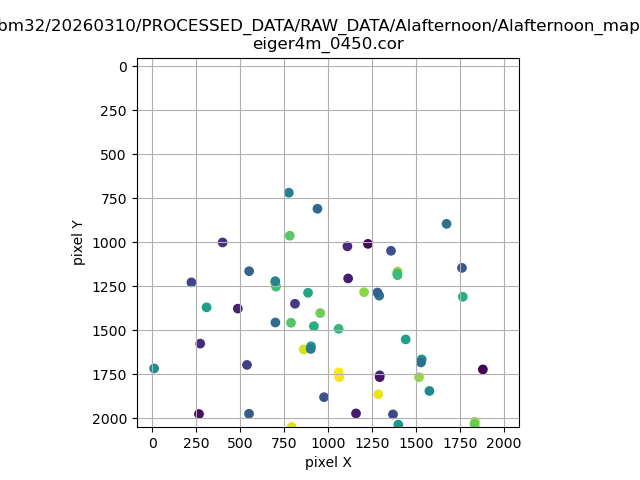

In [28]:
# Plot laue pattern of a given image
if 1:
    print('corfilefolder is', corfilefolder)
    imageindex =450
    
    filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    if expId == 'a322812':
        #filename = os.path.join(corfilefolder,f'p{prefixfilename}%04d.cor'%imageindex)
        #filename = os.path.join(corfilefolder,'Al2O3substrates.cor')
        pass
    
    from LaueTools.LaueDataResultsPlots import PlotPeakPos
    ff, aa = PlotPeakPos(filename, frame='pixel', showindex=False,)#True)
    if aa:
        aa.grid()
        fol = Path(filename).parent
        fn = Path(filename).name
        aa.set_title(f'{fol}\n{fn}')

## some results orientation matrices

In [54]:
if expId == '322812':
    # DATASET_EXAMPLE=='Al/Al2Cu':
    Al2O3spots = [0, 2, 4, 5, 6, 7, 8, 9, 11, 12, 14, 19, 20, 22, 26, 28, 30, 31, 32, 33, 34,
                  36, 41, 47, 48, 49, 54, 58, 59, 62, 67, 82, 89, 90, 91, 92, 93, 94, 104, 107,
                  117, 119, 134, 135, 139, 141, 145, 148, 155, 162, 180, 183, 187, 188, 191, 197,
                  217, 221, 222, 224,
                  231, 234, 236, 253, 256, 261, 277, 295, 320, 321, 322, 327, 334, 345, 347, 367, 398, 403]
    Al2O3_1 = np.array([[-0.60826032, -0.75608103, -0.23205090],
                        [-0.05385452, 0.33412222, -0.93619230],
                        [0.79214276, -0.56128431, -0.24275414]])
    Al = np.array([[0.7137304815562723, -0.32484826788496546, -0.6189301007684953], 
                   [0.17670781204314376, 0.9378438988921185, -0.2909351071253641],
                   [0.6761917710332851, 0.09937432302387145, 0.7299839723927166]])
    Al2Cu = np.array([[-0.22400746452984244, 0.5537594407709006, 0.8022866301439912], 
                      [-0.9573545423301522, -0.2783487963905804, -0.07520625862254801], 
                      [0.18261536418532037, -0.7858999473682405, 0.5920433997814928]])
    
    testMAtrix = np.array([[0.8824300572185522, 0.19919854054607591, 0.4243793753282497], 
                           [-0.34470667875219557, 0.8905450642933267, 0.2940815804229471], 
                           [-0.32033857637578, -0.4051652260710348, 0.8546980892790703]])

## [OPTION] Remove some spots

- from the substrate (blacklisted spots in a file)
- previously indexed (list of indices)

In [30]:
if DATASET_EXAMPLE == 'Al/Al2Cu':
    imageindex = 0 # 
    filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    
    imageindex_black = 6
    blacklistfile = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex_black)
    corfile_written = removespots_fromfile(blacklistfile, filename, CCDLabel='sCMOS')
    
    print('purged file written in ',corfile_written)

In [31]:
if DATASET_EXAMPLE == 'Al/Al2Cu':
    imageindex = 6 #  
    filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    
    blacklistindices = Al2O3spots
    blacklistindices = np.arange(50)
    corfile_written = removespots_fromlist(blacklistindices, filename, CCDLabel='sCMOS')
    
    print('purged file written in ',corfile_written)

In [32]:
if DATASET_EXAMPLE == 'Al/Al2Cu':
    filecor1 = os.path.join(corfilefolder,f'p{prefixfilename}0000.cor')  # Al only
    filecor2 = os.path.join(corfilefolder,f'p{prefixfilename}0006.cor')  # Al2Cu
    outputfilename = 'AlandAl2Cu'
    corfile_written = merge_corfiles(filecor1, filecor2, outputfilename, corfilefolder)
    print('merged file written in ',corfile_written)

In [33]:
if DATASET_EXAMPLE == 'Al/Al2Cu':
    imageindex = 0 # 
    filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    
    blacklistfile = os.path.join(corfilefolder,'AlandAl2Cu.cor')
    corfile_written = removespots_fromfile(blacklistfile, filename, outputfilename='Al2O3substrates',CCDLabel='sCMOS')
    
    print('purged file written in ',corfile_written)

## TEST Indexing single file with index_refine

In [29]:
imageindex = 800 #  # for Zr : 276 Zr contains two grains ! UB_275 and UB_277

outputlistindices = True
t0 = time.time()
filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
#filename1 = os.path.join(maindatafolder,f'dat_{prefixfilename}%04d_LT_0.cor'%imageindex)
#filename2 = os.path.join(corfilefolder,'ech28_withoutspots_0006.cor')  # spots without Al2O3

if expId == 'a322812':
    filename = os.path.join(corfilefolder,f'p{prefixfilename}%04d.cor'%imageindex)

print('filename',filename)

ignorefitfileresults = True # redo analysis whatever .fit file results already exist
# ignorefitfileresults = False # perform analysis only if corresonding .Fit file results are missing
writefitfile = True
starting_grainindex = 500

MODE = 0 # default

verbosefilename = True
verboselevel = 1

LUT=None

key_material = 'Al'
dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
dict_indexrefine['central spots indices']=np.arange(20).tolist()  # 100
#dict_indexrefine['central spots indices']=np.arange(80,90).tolist()
dict_indexrefine['NBMAXPROBED']=max(dict_indexrefine['central spots indices'])+1
dict_indexrefine['nlutmax']=5
dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.2
maxnbspots_MReval, stop_Nb_Matches = 200, 300 # 25

if DATASET_EXAMPLE=='Al/Al2Cu':
    if 0: # img_0000
        key_material = 'Al'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        dict_indexrefine['central spots indices']=np.arange(200).tolist()  # 100
        #dict_indexrefine['central spots indices']=np.arange(80,90).tolist()
        dict_indexrefine['NBMAXPROBED']=max(dict_indexrefine['central spots indices'])+1
        dict_indexrefine['nlutmax']=3
        dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.5
        maxnbspots_MReval, stop_Nb_Matches = 200, 300 # 25

    if 0:
        # img_0000
        MODE = 2
        key_material = 'Al'
        usepreviousUB=[Al]
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        
        dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.5
        # hte following is useful if skipindexing=False
        # dict_indexrefine['central spots indices']=np.arange(100).tolist()
        # dict_indexrefine['central spots indices']=np.arange(80,90).tolist()
        # dict_indexrefine['NBMAXPROBED']=101
        # dict_indexrefine['nlutmax']=4
        # maxnbspots_MReval, stop_Nb_Matches = 200, 25
    if 1: # img_0006
        key_material = 'Al2Cu'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        dict_indexrefine['central spots indices']=np.arange(20).tolist()
        #dict_indexrefine['central spots indices']=[3, 10, 11]
        dict_indexrefine['NBMAXPROBED']=21
        dict_indexrefine['nlutmax']=3
        maxnbspots_MReval, stop_Nb_Matches = 200, 140

    if 0:
        key_material = 'Al2O3'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        dict_indexrefine['central spots indices']=np.arange(20).tolist()  # for substrate 1
        dict_indexrefine['central spots indices']= [3, 16, 21]
        dict_indexrefine['NBMAXPROBED']=150
        dict_indexrefine['nlutmax']=5
        maxnbspots_MReval, stop_Nb_Matches = 200, 80

if DATASET_EXAMPLE == 'Zr':
    if 1:
        key_material = 'Zr'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        dict_indexrefine['central spots indices']=np.arange(20).tolist()
        dict_indexrefine['central spots indices']=[0]
        dict_indexrefine['NBMAXPROBED']=80
        dict_indexrefine['nlutmax']=5
        maxnbspots_MReval, stop_Nb_Matches = 200, 60 # 25

    if 0:
        key_material = 'Cr'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'_{key_material}')
        dict_indexrefine['central spots indices']=np.arange(20).tolist()
        dict_indexrefine['NBMAXPROBED']=21
        dict_indexrefine['nlutmax']=4
    
    # key_material = 'Cr'
    # dirnameout_fitfile = Path(str(fitfilefolder)+'_Cr')
    # dict_indexrefine['central spots indices']=np.arange(20).tolist()
    # dict_indexrefine['NBMAXPROBED']=60  # large
    # dict_indexrefine['nlutmax']=3   # 3 !!

#### FROM SCRATCH #############
if MODE == 0:
    nbGrainstoFind = 1  # from 1  to  n 
    usepreviousUB = None
    skipindexing = False
    # some tests to reduce computing time!
    starting_grainindex = 300
    printindexingstats=False # (True, interesting for useinternalmultiprocessing = False)

###  USE PREVIOUS MATRIX in fit file to ONLY refine  ######
elif MODE == 1:
    nbGrainstoFind = 1
    usepreviousUB = 'fromfitfile'  # will read ####_g0.fit
    skipindexing = True

###  USE PREVIOUS MATRIX from a list of UB matrices FIRST and THEN to ONLY refine ######
elif MODE == 2:
    skipindexing = True
    nbGrainstoFind = max(len(usepreviousUB),nbGrainstoFind)
    crudeMReval=False # True does not work !!!!!
    verboselevel = 1

###  USE PREVIOUS MATRIX in .fit file FIRST and THEN if needed perform indexing from scratch  ###
###  indexing form scratch is launched if there are less proposed matrix than `nbGrainstoFind`
elif MODE == 3:
    nbGrainstoFind = 1
    previousResults = 'fromfitfile'
    skipindexing = False

###  USE PREVIOUS MATRIX from a list of UB matrices FIRST and THEN if needed perform indexing from scratch  ###
###  indexing form scratch is launched if there are less proposed matrix than `nbGrainstoFind`
elif MODE == 4:
    usepreviousUB = [UB_1000_Zr]#UB_275, UB_277]  # Zr
    #previousResults = [UB_2, UB_1]  # Zn
    #previousResults = [UB_Zr_828] # Zr
    skipindexing = False
    nbGrainstoFind = max(len(previousResults),nbGrainstoFind)

#  -----------  end of user input ------------------
useinternalmultiprocessing=True

print('skipindexing',skipindexing)
largestspotindex_setA = max(dict_indexrefine['central spots indices'])
if largestspotindex_setA>=dict_indexrefine['NBMAXPROBED']:
    GT.printyellow(f'''dict_indexrefine['NBMAXPROBED'] is too low. It should be at least: {largestspotindex_setA+1}''')
else:
    if outputlistindices:
        RES = index_refine(filename)
        print(RES)
        res = RES[:4]
        spotsindexedindices = RES[-1]
    else:
        res = index_refine(filename)
        spotsindexedindices = None
    ########   print results #######
    print('------- Indexing single dataset  ------')
    if useinternalmultiprocessing:
        print('but with multiprocessing ')
    else:
        print('without multiprocessing')
    print('Stopping level of Nb of Matches', stop_Nb_Matches)
    print(f'image index {res[0]}')
    #print(f'Initial number of spots {res[0]}')
    #print(f'UB matrix(ces) found: {res[1]}')
    #print(f'Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    for gub, score in zip(res[1], res[2]):
        gindex, ub = gub
        print('ub',ub)
        nir, mr = score[1]
        if nir>20 and mr > 33:
            GT.printgreen(f'Nb indexed Reflections: {nir}, Matching Rate {mr:.2f}%')
        else:
            GT.printred(f'Nb indexed Reflections: {nir}, Matching Rate {mr:.2f}%. These (poor?) results may be not reliable')
        if ub is not None: print('UB matrix found: np.array('+str(ub.tolist())+')\n')
    # if len(res[1]) <= 1:
    #     GT.printgreen(f'UB matrix(ces) found: {res[1]}')
    #     GT.printgreen(f'Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    # else:
    #     GT.printred(f'UB matrix(ces) found: {res[1]}')
    #     GT.printred(f'Last Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    print('\nInfo: ', res[-1])

    print('Elapsed time: %.2f seconds'%(time.time()-t0))

filename /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0800.cor
skipindexing False

In importdatafromfile(): 
Import Data for DATASET indexation procedure
fullpathfile in importdatafromfile() /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0800.cor
nb of spots in .cor file /data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0800.cor  is  57
add_props.shape (9, 57)
current used MATCHINGRATE_FOR_PREVIOUSRESULTS 1.0
writing fit file -------------------------
for grainindex= 300
For eiger4m_0800.cor
grain #300, nb indexed spots: 8,  #spotindex [1, 2, 5, 12, 19, 21, 28, 45]
[800, [(300, array([[ 0.712780952356555, -0.680162967478989, -0.174806814956147],
       [ 0.70333400425288 ,  0.683841114568755,  0.196387362581326],
       [-0.015116782291012, -0.261585205400375,  0.964782875151546]]))], [(30

## PLOT exp. and  indexed spots (red stars)

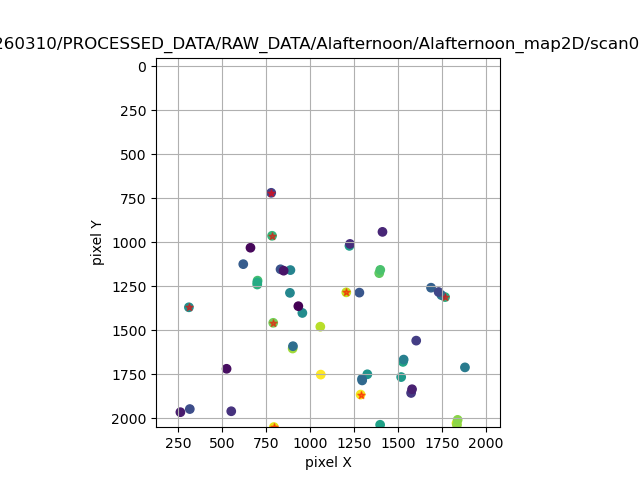

In [30]:
import LaueTools.lauecore as LTcore
XYindexed = IOLT.readfile_cor(filename)[0][spotsindexedindices,2:4]
# Plot laue pattern of a given image
from LaueTools.LaueDataResultsPlots import PlotPeakPos
ff, aa = PlotPeakPos(filename, frame='pixel', showindex=False,)#True)  # showindex=True to show spot index
if aa: # add red star markers for indexed spot
    aa.grid()
    aa.set_title(filename)
    aa.scatter(XYindexed[:,0],(XYindexed[:,1]), marker='*', s=30, alpha=0.5, c='r')

# TODO plot h k l miller indices

In [ ]:
# TODO
# blacklisted_spots = spotsindexedindices
# blacklist = fitfile with  listindex (optionally)
# blacklist = corfile with listindex (optionnaly)

In [82]:
starting_imageindex = 0
final_imageindex = 3

if DATASET_EXAMPLE=='Zr':
        key_material = 'Zr'
        dirnameout_fitfile = Path(str(fitfilefolder)+f'JSM_{key_material}')
        dict_indexrefine['central spots indices']=[0,1,2,3,4]
        dict_indexrefine['NBMAXPROBED']=20
        dict_indexrefine['nlutmax']=3
        
        # key_material = 'Cr'
        # dirnameout_fitfile = Path(str(fitfilefolder)+'_Cr')
        # dict_indexrefine['central spots indices']=np.arange(20).tolist()
        # dict_indexrefine['NBMAXPROBED']=60  # large
        # dict_indexrefine['nlutmax']=3   # 3 !!

if DATASET_EXAMPLE=='Al/Al2Cu':
    key_material = 'Al'
    dirnameout_fitfile = Path(str(fitfilefolder)+f'JSM_{key_material}')
    dict_indexrefine['central spots indices']=np.arange(40,150).tolist() #[0,1,2,3,4]
    dict_indexrefine['NBMAXPROBED']=151
    dict_indexrefine['nlutmax']=3
    
for imageindex in range(starting_imageindex,final_imageindex+1):

    filename = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex)
    # if os.stat(filename).st_size<=17:
    #     GT.printred('.cor file is empty ...')
    #     GT.printred('Do a test on other file please ...\n\n')
    
    ignorefitfileresults = True # redo analysis whatever .fit file results already exist
    # ignorefitfileresults = False # perform analysis only if corresonding .Fit file results are missing
    
    writefitfile = True
    
    starting_grainindex = 500
    
    MODE = 0  #0
    verboselevel = 0
    verbosefilename = True
    LUT=None
    
    #### FROM SCRATCH #############
    if MODE == 0:
        nbGrainstoFind = 1  # from 1  to  n 
        usepreviousUB = None
        skipindexing = False
        
        # some tests to reduce computing time!
        starting_grainindex = 300
        maxnbspots_MReval, stop_Nb_Matches = 200000, 20
        #maxnbspots_MReval, stop_Nb_Matches = 10000, 50
        
        printindexingstats=False # (True, interesting for useinternalmultiprocessing = False)
    
    ###  USE PREVIOUS MATRIX in fit file to ONLY refine  ######
    elif MODE == 1:
        nbGrainstoFind = 1
        previousResults = 'fromfitfile'  # will read ####_g0.fit
        skipindexing = True
    
    ###  USE PREVIOUS MATRIX from a list of UB matrices FIRST and THEN to ONLY refine ######
    elif MODE == 2:
        mytestmatrices = [np.eye(3),np.eye(3)]  # [UB_1000_Zr]
        usepreviousUB = mytestmatrices  # from 1  to  n ] #[UB_275, UB_277] #[UB_IMG208_Zr_G0]  # Zr
        skipindexing = True
        nbGrainstoFind = max(len(usepreviousUB),nbGrainstoFind)
    
    ###  USE PREVIOUS MATRIX in .fit file FIRST and THEN if needed perform indexing from scratch  ###
    ###  indexing form scratch is launched if there are less proposed matrix than `nbGrainstoFind`
    elif MODE == 3:
        nbGrainstoFind = 1
        usepreviousUB = 'fromfitfile'
        skipindexing = False
    
    ###  USE PREVIOUS MATRIX from a list of UB matrices FIRST and THEN if needed perform indexing from scratch  ###
    ###  indexing form scratch is launched if there are less proposed matrix than `nbGrainstoFind`
    elif MODE == 4:
        mytestmatrices = [np.eye(3),np.eye(3)]  # UB_1000_Zr
        usepreviousUB = mytestmatrices #UB_275, UB_277]  # Zr
        #previousResults = [UB_2, UB_1]  # Zn
        #previousResults = [UB_Zr_828] # Zr
        skipindexing = False
        nbGrainstoFind = max(len(usepreviousUB),nbGrainstoFind)
    
    useinternalmultiprocessing=True
    
    res = index_refine(filename)
    
    # print('------- Indexing single dataset  ------')
    if useinternalmultiprocessing:
        print('but with multiprocessing ')
    else:
        print('without multiprocessing')
    # print('Stopping level of Nb of Matches', stop_Nb_Matches)
    # print(f'image index {res[0]}')
    #print(f'Initial number of spots {res[0]}')
    #print(f'UB matrix(ces) found: {res[1]}')
    #print(f'Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    
    for gub, score in zip(res[1], res[2]):
        gindex, ub = gub
        nir, mr = score[1]
        if nir>20 and mr > 20:
            GT.printgreen(f'Nb indexed Reflections: {nir}, Matching Rate {mr:.2f}%')
        else:
            GT.printred(f'Nb indexed Reflections: {nir}, Matching Rate {mr:.2f}%')
        # print('UB matrix found: np.array('+str(ub.tolist())+')\n')
    # if len(res[1]) <= 1:
    #     GT.printgreen(f'UB matrix(ces) found: {res[1]}')
    #     GT.printgreen(f'Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    # else:
    #     GT.printred(f'UB matrix(ces) found: {res[1]}')
    #     GT.printred(f'Last Matching rate (grain index, [Nb of indexed spots, MR (%)]): {res[2]}')
    # print('\nInfo: ', res[-1])
    # print('Elapsed time: %.2f seconds'%(time.time()-t0))
    print('res',res)

Considering ech28_0000.cor
grain #300, nb indexed spots: 28,  #spotindex [24, 47, 49, 76, 97, 103, 154, 161, 162, 169, 172, 174, 183, 188, 190, 191, 195, 222, 234, 243, 246, 252, 259, 266, 279, 287, 288, 289]
grain #301, #spotindex []
but with multiprocessing 
Nb indexed Reflections: 28, Matching Rate 48.28%
res [0, [(300, array([[ 0.714223978740014, -0.324712733477553, -0.618964382926122],
       [ 0.177042261855667,  0.937366773409919, -0.291001030541162],
       [ 0.675739240222296,  0.098471123193747,  0.730018065198583]]))], [(300, [28, 48.275862068965516])], ' Treated by IndexSpotsSet().']
Considering ech28_0001.cor
grain #300, nb indexed spots: 26,  #spotindex [29, 52, 53, 61, 69, 99, 105, 137, 141, 161, 163, 167, 168, 171, 174, 188, 189, 191, 203, 205, 209, 216, 220, 231, 244, 266]
grain #301, #spotindex []
but with multiprocessing 
Nb indexed Reflections: 26, Matching Rate 47.27%
res [1, [(300, array([[ 0.720331091748838, -0.328770486708277, -0.612173221246097],
       [ 0.179

## [OPTION] TEST loop with index_refine

# MULTIPROCESSING INDEX & REFINE  .cor files

In [ ]:
pool

In [ ]:
del(pool)

## set index  refine materials parameters

- set user defined parameters for indexing (and refining)


In [31]:
#-------------  user-defined parameters ------------------
nb_cpus =130 # 130 on lbm32gpu1, 40 on ub20, 64 fr-crg, 192 magnifix

# if True reanalyse all .cor images (whatever existing .fit files...) and overwrite results .fit files
# if False, only .cor file with missing corresponding fitfile will be analysed
ignorefitfileresults =True

# if False, indexing from scratch
# if 'fromfitfile', refinement of UB matrix found in corresponding .fit file. If refinement is poor then indexing from scratch
# if elements tuple (nb of matrices, list of UB,0,0)
usepreviousUB = False #(555,[UB_Zr_1],555,555)  # False
#usepreviousUB = [UB_Zr_828]

# inhibit or not indexing from scratch after having tested previous results
# True if one wants to catch only 1 grain
# False to allow indexing from scratch
skipindexing = False

# generally True to save permanently results on disk with .fit file
writefitfile = True
verboselevel = 0
MODE = 0 #default

MODE = 0
key_material = 'Al'
dirnameout_fitfile = Path(str(fitfilefolder)+'_Al')
dict_indexrefine['central spots indices']=np.arange(0,20).tolist()
dict_indexrefine['NBMAXPROBED']=max(dict_indexrefine['central spots indices'])+1
dict_indexrefine['nlutmax']=5
dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.2
stop_Nb_Matches =25 #
verbosefilename = True

if DATASET_EXAMPLE=='Al/Al2Cu':
    if 1:
        MODE = 0
        key_material = 'Al'
        dirnameout_fitfile = Path(str(fitfilefolder)+'_Al')
        dict_indexrefine['central spots indices']=np.arange(0,150).tolist()
        dict_indexrefine['NBMAXPROBED']=max(dict_indexrefine['central spots indices'])+1
        dict_indexrefine['nlutmax']=3
        dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.5
        stop_Nb_Matches =25 #
        verbosefilename = True
    if 0:
        MODE = 2
        key_material = 'Al'
        usepreviousUB = [Al]
        dict_indexrefine['MATCHINGRATE_ANGLE_TOL']=0.5
        dirnameout_fitfile = Path(str(fitfilefolder)+'_Al_UB')
        dict_indexrefine['central spots indices']=np.arange(0,150).tolist()
        dict_indexrefine['NBMAXPROBED']=151
        dict_indexrefine['nlutmax']=4
        stop_Nb_Matches =25 #

if DATASET_EXAMPLE=='Zr':
    verboselevel = 0
    key_material = 'Zr'
    dirnameout_fitfile = Path(str(fitfilefolder)+'_Zr')
    dict_indexrefine['central spots indices']=[0,1,2,3]
    dict_indexrefine['NBMAXPROBED']=12
    dict_indexrefine['nlutmax']=3

    # # Cr ----------
    # key_material = 'Cr'
    # dirnameout_fitfile = Path(str(fitfilefolder)+'_Cr')
    # dict_indexrefine['central spots indices']=np.arange(4).tolist()
    # dict_indexrefine['NBMAXPROBED']=30  # large
    # dict_indexrefine['nlutmax']=3   # 3 !!

    printindexingstats=False # (True, interesting for useinternalmultiprocessing = False)
    stop_Nb_Matches =60
    
#### FROM SCRATCH #############
if MODE == 0:
   
    nbGrainstoFind = 1  # from 1  to  n 
    usepreviousUB = None
    skipindexing = False
    
    # some tests to reduce computing time!
    starting_grainindex = 0
    # --------------------------
    
elif MODE == 2:
    
    nbGrainstoFind = 1  # from 1  to  n
    skipindexing = True
    nbGrainstoFind = max(len(usepreviousUB),nbGrainstoFind)

    


## Set the set of .cor files to analyse

- set flag`verbosefilename` to print some info / dataset
- set `listfiles` corresponding to set data to analyze (all or part of it)
- use as many cpus. 1 cpu for 1 image index dataset
- `useinternalmultiprocessing`=False  (MANDATORY)

In [32]:
verbosefilename = False

#-----------SET `listfiles` ----------------------------------
#cor_filelist = [os.path.join(corfilefolder,_file) for _file in os.listdir(corfilefolder) if (_file.startswith("img_") and _file.endswith(".cor"))]

# -------   define `listfiles` (SELECT set of .cor files)  --------------
# CHOICE A : all available in a folder
# use better Path.glob('*.cor') ...
cor_filelist = [str(ff) for ff in sorted(Path(corfilefolder).glob(f'{prefixfilename}*.cor'))]

# CHOICE B : part of data in a folder
# to test or handle only a subset of the list of files by image index
startindex, finalindex = 29300, 30100# + 3*nb_cpus
# a list of indices
listindices = np.arange(startindex,finalindex+1,1)

# a list of indices corresponding to a rectangle in the sample map (ROI)
listindices = GT.extract2Dslice(2, (20, 20), np.arange(mapdims[0]*mapdims[1]).reshape(invmapdims)).ravel()
# selectedlistfiles = [ff for ff in cor_filelist if GT.getfileindex(ff) in listindices]
# TODO  add prefix in getfileindex

### FINAL choice of the list of files  user choice of `listindices`
listfiles= cor_filelist[:]#  or even listfiles = cor_filelist[547:547+2*nb_cpus]
#listfiles = selectedlistfiles
# ------- END of define `listfiles`  --------------

# ---------------------------------------------------------
#---------END OF user-defined parameters ------------------
#----------------------------------------------------------
print('First 5 .Cor files to be analyszed of listfiles',listfiles[:5])
print('Nb of .cor files in listfiles',len(listfiles))
if mapdims:
    print('mapdims', mapdims)
    print('nb of max of .cor files in the map', mapdims[0]*mapdims[1])
# MULTIPROCESSING of index_refine and useinternalmultiprocessing=False

# building LUT
if mymaterials is not None and key_material in mymaterials:
    latticeparameters = mymaterials[key_material][1]
else:
    latticeparameters = DictLT.dict_Materials[key_material][1]
LUT = IAL.build_AnglesLUT_fromlatticeparameters(latticeparameters, dict_indexrefine['nlutmax'])

nb_corfiles = len(listfiles)

t4 = time.time()

outputlistindices=False
useinternalmultiprocessing=False

with multiprocessing.Pool(processes=nb_cpus) as pool:
        allresults = []
        # imap_unordered yields results as soon as they finish
        for r in tqdm(pool.imap_unordered(index_refine, listfiles, chunksize=1), total=nb_corfiles):
            allresults.append(r)

t5 = time.time()
minutes = int(np.ceil(t5 - t4) // 60)
seconds = int(np.ceil(t5 - t4)  % 60)

print(f"It took {minutes}mins and {seconds}s to index {nb_corfiles} images with {nb_cpus} cpus.")
if not multiprocessing.active_children():
    GT.printgreen("Done!\n\n")

imin:imax + 1, jmin:jmax + 1 0 21 0 23
First 5 .Cor files to be analyszed of listfiles ['/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0000.cor', '/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0001.cor', '/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0002.cor', '/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0003.cor', '/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/RAW_DATA/Alafternoon/Alafternoon_map2D/scan0001/corfiles/eiger4m_0004.cor']
Nb of .cor files in listfiles 826
mapdims (51, 51)
nb of max of .cor files in the map 2601


100%|██████████| 826/826 [00:57<00:00, 14.41it/s]

It took 0mins and 59s to index 826 images with 130 cpus.
Done!




In [33]:
dirnameout_fitfile

PosixPath('/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/fitfiles_Al')

## [OPTION] Loop on index_refine2 with internal multiprocessing

see getOrientMatrices() in IndexingAnglesLut.py

In [36]:
# loop of index_refine2 and useinternalmultiprocessing=False   9 sec /image (2 grains of Zr)
# loop of index_refine2 and useinternalmultiprocessing=True   9 sec /image (2 grains of Zr)

#-------------  user-defined parameters ------------------
nb_cpus = 120

# if True reanalyse all .cor images (whatever existing .fit files...) and overwrite results .fit files
# if False, only .cor file with missing corresponding fitfile will be analysed
ignorefitfileresults =True

# if False, indexing from scratch
# if 'fromfitfile', refinement of UB matrix found in corresponding .fit file. If refinement is poor then indexing from scratch
# if elements tuple (nb of matrices, list of UB,0,0)
usepreviousUB = False #(555,[UB_Zr_1],555,555)  # False
#usepreviousUB = (555,[UB_Zr_828],555,555)  # False

# inhibit or not indexing from scratch after having tested previous results
# True if one wants to catch only 1 grain
# False to allow indexing from scratch
skipindexing = False

# generally True to save permanently results on disk with .fit file
writefitfile = True

MODE = 0

#### FROM SCRATCH #############
if MODE == 0:
   
    nbGrainstoFind = 1  # from 1  to  n 
    previousResults = None
    skipindexing = False
    
    # some tests to reduce computing time!
    starting_grainindex = 0

    # # Cr ----------
    # key_material = 'Cr'
    # dirnameout_fitfile = Path(str(fitfilefolder)+'_Cr')
    # dict_indexrefine['central spots indices']=np.arange(4).tolist()
    # dict_indexrefine['NBMAXPROBED']=30  # large
    # dict_indexrefine['nlutmax']=3   # 3 !!
    
    verboselevel = 0
    if DATASET_EXAMPLE=='Zr':
        key_material = 'Zr'
        dict_indexrefine['nlutmax']=3
        dirnameout_fitfile = Path(str(fitfilefolder)+'_Zr')
        if 0:  # 1 image / 15 s
            dict_indexrefine['central spots indices']=[0,1,2,3,4,5]
            dict_indexrefine['NBMAXPROBED']=20
        if 0:  # 1 image / 12 s but less results
            dict_indexrefine['central spots indices']=[0,1,2]
            dict_indexrefine['NBMAXPROBED']=20
        if 1:  # 1
            dict_indexrefine['central spots indices']=[0,1]
            dict_indexrefine['NBMAXPROBED']=40
    
    printindexingstats=False # (True, interesting for useinternalmultiprocessing = False)
    #stop_Nb_Matches = 60
    maxnbspots_MReval, stop_Nb_Matches = 250, 30    
        
    
    if DATASET_EXAMPLE=='Al/Al2Cu':
        verboselevel = 0
        nbGrainstoFind = 1
        key_material = 'Al'
        dirnameout_fitfile = Path(str(fitfilefolder)+'_Al')
        dict_indexrefine['central spots indices']=np.arange(40,100).tolist()
        dict_indexrefine['NBMAXPROBED']=101
        dict_indexrefine['nlutmax']=3

        printindexingstats=False # (True, interesting for useinternalmultiprocessing = False)
        stop_Nb_Matches =20 #

    # --------------------------

#-----------set `listfiles` ----------------------------------
#cor_filelist = [os.path.join(corfilefolder,_file) for _file in os.listdir(corfilefolder) if (_file.startswith("img_") and _file.endswith(".cor"))]
if usepreviousUB is None:
    raise ValueError('usepreviousUB can not be None. You meant False')

# -------   define `listfiles` (SELECT set of .cor files)  --------------
# Choice A
# use better Path.glob('*.cor') ...
cor_filelist = [str(ff) for ff in sorted(Path(corfilefolder).glob(f'{prefixfilename}*.cor'))]

# Choice B
# to test or handle only a subset of the list of files by image index
startindex, finalindex = 0, 200# 
# a list of indices
listindices = np.arange(startindex,finalindex+1,1)

# a list of indices corresponding to a rectangle in the sample map (ROI)
listindices = GT.extract2Dslice(2, (20, 20), np.arange(mapdims[0]*mapdims[1]).reshape(invmapdims)).ravel()
selectedlistfiles = [ff for ff in cor_filelist if GT.getfileindex(ff) in listindices]

### final choice of the list of files  user choice of `listindices`
listfiles= cor_filelist[:2000]#  or even listfiles = cor_filelist[547:547+2*nb_cpus]
#listfiles = selectedlistfiles
# ------- END of define `listfiles`  --------------

# ---------------------------------------------------------
#---------END OF user-defined parameters ------------------
#----------------------------------------------------------
# building LUT
if mymaterials is not None and key_material in mymaterials:
    latticeparameters = mymaterials[key_material][1]
else:
    latticeparameters = DictLT.dict_Materials[key_material][1]
LUT = IAL.build_AnglesLUT_fromlatticeparameters(latticeparameters, dict_indexrefine['nlutmax'])

nb_corfiles = len(listfiles)

t4 = time.time()

allresults = []

useinternalmultiprocessing=True
for fname in tqdm(listfiles, total=nb_corfiles):
    r = index_refine(fname)
    allresults.append(r)

t5 = time.time()
minutes = int(np.ceil(t5 - t4) // 60)
seconds = int(np.ceil(t5 - t4)  % 60)

print(f"It took {minutes}mins and {seconds}s to index {nb_corfiles} images with {nb_cpus} cpus.")


imin:imax + 1, jmin:jmax + 1 0 17 0 17


  0%|                                                                                                    | 0/289 [00:00<?, ?it/s]


NameError: name 'index_refine2' is not defined

## POST PROCESS RESULTS

In [29]:
print('Process and summarize results')
        
# Results Summary:
treatedimages = []
# mapdims   fast, slow
invmapdims = mapdims[1],mapdims[0]   # slow, fast
Nbindexedimages2D = np.empty(invmapdims)  # nb of indexed spots 
MRindexedimages2D = np.empty(invmapdims)  # matching rate
Nbindexedimages2D[:]=np.nan
MRindexedimages2D[:]=np.nan
maskindexed2D = False*np.ones(invmapdims, dtype=bool)
grainlistindices = []
nonindexedimages = []
indexedimages = []   # 
n2 =mapdims[0]  # fast axis

print('n2',n2)
print('Nbindexedimages2D.shape', Nbindexedimages2D.shape)

for elem in tqdm(allresults):

    ix, dictmatrix, dictMR, info = elem
    treatedimages.append(ix)
    #print(dictmatrix)
    if len(dictmatrix)>0:
        maskindexed2D[ix//n2, ix%n2]=True
        grainlistindices.append(ix)
        indexedimages.append(ix)
        nbindexed, MR = dictMR[0][1]
        if isinstance(nbindexed, int):
            Nbindexedimages2D[ix//n2, ix%n2]=nbindexed
        if isinstance(MR, float):
            MRindexedimages2D[ix//n2, ix%n2]=MR
    else:
        nonindexedimages.append(ix)
        maskindexed2D[ix//n2, ix%n2]=False

GT.printgreen('Done !')

Process and summarize results
n2 17
Nbindexedimages2D.shape (17, 17)


100%|██████████████████████████████████████████████████████████████████████████████████████| 289/289 [00:00<00:00, 437284.94it/s]

Done !


In [ ]:
del(pool)

### [SAVE] `allresults`

In [30]:
import pickle, datetime
#------------ user inputs -------------
SAVE_ALLRESULTS_PICKLE = True

saving_folder = corfilefolder
mystamp = 'Almap_UB_angle0p1'
saving_filename = 'allresults_%s.pickle'%mystamp


#------------end of user inputs -------------
if SAVE_ALLRESULTS_PICKLE: # SAVE
    fullpathsaving = os.path.join(saving_folder,saving_filename)
    
    WRITEFILE=True
    if Path(fullpathsaving).exists():
        GT.printred('The following File already exists!')
        if input('Do you want to overwrite it?') not in ('y','Y','yes','YES'):
            print('Please change the filename if you really want to save your results')
            WRITEFILE=False
            
if WRITEFILE:    
    dict_scan_data = {'maindatafolder':maindatafolder,
                     'subfolderscandata':subfolderscandata,
                      'imagefolder':imagefolder,
                     'datfilefolder':datfilefolder,
                     'corfilefolder':corfilefolder,
                      'fitfilefolder':fitfilefolder,
                     'prefixfilename':prefixfilename,
                     'suffix':suffix,
                     'CCDLabel':CCDLabel,
                     'sizeofzeropadding':sizeofzeropadding,
                     'detfile':detfile,
                     'mapdims':mapdims,
                     'invmapdims':invmapdims}
    
    dict_index_refine_for_mpi ={'e_min':e_min,
                      'e_max':e_max,
                      'e_max_MR':e_max_MR,
                      'key_material':key_material,
                      'nbGrainstoFind':nbGrainstoFind,
                      'depth':depth,
                      'dict_indexrefine':dict_indexrefine,
                      'MatchingRate_List':MatchingRate_List,
                      'MIN_NUMBERSPOTS_FOR_INDEXING':MIN_NUMBERSPOTS_FOR_INDEXING,
                      'MAX_NUMBERSPOTS_FOR_INDEXING':MAX_NUMBERSPOTS_FOR_INDEXING}
    
    dict_info_collect_mpi = {'nb_cpus':nb_cpus,
                            'ignorefitfileresults':ignorefitfileresults,
                            'usepreviousUB':usepreviousUB,
                            'skipindexing':skipindexing,
                            'writefitfile':writefitfile}
    
    dict_results_summary = {'treatedimages':treatedimages,
                           'nonindexedimages':nonindexedimages,
                           'indexedimages':indexedimages,
                           'maskindexed2D':maskindexed2D,
                            'Nbindexedimages2D':Nbindexedimages2D,
                            'MRindexedimages2D':MRindexedimages2D,
                            'grainlistindices':grainlistindices}
    
    dictresults={}
    dictresults['allresults']=allresults
    dictresults['dict_scan_data'] = dict_scan_data
    dictresults['dict_index_refine_for_mpi'] = dict_index_refine_for_mpi
    dictresults['dict_info_collect_mpi'] = dict_info_collect_mpi
    dictresults['dict_results_summary'] = dict_results_summary
    with open(fullpathsaving, 'wb') as f:
        pickle.dump(dictresults, f)
        GT.printgreen(f'\nLast allresults.pickle file was saved at {datetime.datetime.now()}:')
        GT.printgreen(f'{fullpathsaving}')

The following File already exists!


Do you want to overwrite it? yes



Last allresults.pickle file was saved at 2026-01-21 15:36:28.701517:
/data/bm32/inhouse/data/laue/32-02-812/PROCESSED_DATA/corfiles/allresults_Almap_UB_angle0p1.pickle


### [LOAD] `allresults` from "allresults" .pickle file

In [42]:
if 0: #LOAD
    fullpathsaving = '/data/projects/zndendrites/ma6034/bm32/20240625/RAW_DATA/'
    fullpathsaving += 'sample1_test/sample1_test_sample5-30m-new2-coarse-large/scan0001/'
    fullpathsaving += 'datfiles_notebook/allresults_G218.pickle'
    
    fullpathsaving ='/data/projects/mapgrainxl/blc15488/bm32/20240601/RAW_DATA/ech15/ech15_map2Dexpo0p1sec/scan0001/img_CORfiles/allresults_G1.pickle'

    if input('\n\n\n?? ARE YOU SURE TO LOAD a previous file and OVERWRITE your current dictresults ??\n\n') in ('y','yes','Y','YES','o','O'):
        with open(fullpathsaving, 'rb') as f:
            dictresults=pickle.load(f)
        allresults = dictresults['allresults']
        dict_scan_data = dictresults['dict_scan_data']
        dict_index_refine_for_mpi= dictresults['dict_index_refine_for_mpi']
        dict_indexrefine = dict_index_refine_for_mpi['dict_indexrefine']
        dict_info_collect_mpi = dictresults['dict_info_collect_mpi']
        dict_results_summary = dictresults['dict_results_summary']
        mapdims = dict_scan_data['mapdims']
        invmapdims = dict_scan_data['invmapdims']
        corfilefolder = dict_scan_data['corfilefolder']
        fitfilefolder = dict_scan_data['fitfilefolder']
        depth = dict_index_refine_for_mpi['depth']
        maskindexed2D = dict_results_summary['maskindexed2D']
        usepreviousUB = dict_info_collect_mpi['usepreviousUB']
        treatedimages = dict_results_summary['treatedimages']
        nonindexedimages = dict_results_summary['nonindexedimages']
        indexedimages = dict_results_summary['indexedimages']
        Nbindexedimages2D = dict_results_summary['Nbindexedimages2D']
        MRindexedimages2D = dict_results_summary['MRindexedimages2D']

## Some visualisations of results (to evaluate quality confidence)

In [31]:
if usepreviousUB:
    print('-------For usepreviousUB-------\n', usepreviousUB)
    print('and last tolerance angle %.2f deg\n'%dict_indexrefine["list matching tol angles"][-1])
    
print('nb of treated datasets :',len(treatedimages))
print('number of non indexed datasets', len(nonindexedimages))
print('number of indexed (or updated) datasets', len(indexedimages))
#print('indexed (or updated) dataset indices list',grainlistindices)

nb of treated datasets : 289
number of non indexed datasets 0
number of indexed (or updated) datasets 289


In [33]:
print('mapdims (fast axis, slow axis)',mapdims)

# depending on scan   dmesh fastmotor .. ..  slowmotor .. ..
if DATASET_EXAMPLE in ('Zr'):
    motorfastaxis = 'yech'
    motorslowaxis = 'xech'
elif DATASET_EXAMPLE in ('Al/Al2Cu',):
    motorfastaxis = 'xech'
    motorslowaxis = 'yech'

mapdims (fast axis, slow axis) (17, 17)


Text(0, 0.5, 'yech')

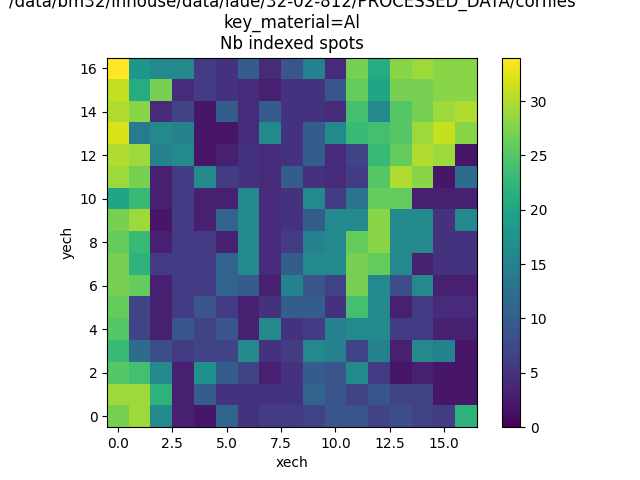

In [34]:
fig2,ax2 = plt.subplots()
Nbindexedimages2Dplot = copy.copy(Nbindexedimages2D)
pp2 = ax2.imshow(Nbindexedimages2Dplot, origin='lower', vmin=0)
txt = f'{corfilefolder}\nkey_material={key_material}'
ax2.set_title(txt+'\nNb indexed spots')
plt.colorbar(pp2)
GT.format_getimageindex_imshow.__defaults__=(invmapdims,)
ax2.format_coord = GT.format_getimageindex_imshow
ax2.set_xlabel(motorfastaxis)
ax2.set_ylabel(motorslowaxis)

Text(0, 0.5, 'yech')

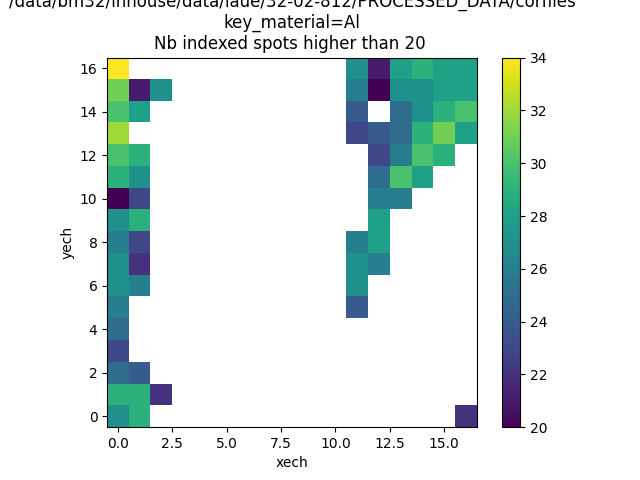

In [36]:
# CHOOSE a mask defined by threshold
# set `condG1`
# Minimum number of Indexed Spots
MinNbthreshold = 20
cond_Nbindexed_poor = Nbindexedimages2Dplot<MinNbthreshold

cond_isnotindexed = np.invert(maskindexed2D)
no_mask = False*np.ones_like(maskindexed2D)
cond_Nbindexed_poor = Nbindexedimages2Dplot<MinNbthreshold

# choice of `condG1` for the plot
condG1 = cond_Nbindexed_poor #no_mask #cond_Nbindexed_poor  cond_isnotindexed
#condG1 = cond_isnotindexed
#condG1 = no_mask

# using mask of indexed and refined data
fig2,ax2 = plt.subplots()
Nbindexedimages2Dplot = copy.copy(Nbindexedimages2D)
Nbindexedimages2Dplot = ma.masked_where(condG1, Nbindexedimages2Dplot)

pp2 = ax2.imshow(Nbindexedimages2Dplot, origin='lower')
ax2.set_title(txt+'\nNb indexed spots higher than %d '%MinNbthreshold)
plt.colorbar(pp2)
GT.format_getimageindex_imshow.__defaults__=(invmapdims,)
ax2.format_coord = GT.format_getimageindex_imshow
ax2.set_xlabel(motorfastaxis)
ax2.set_ylabel(motorslowaxis)

Text(0, 0.5, 'yech')

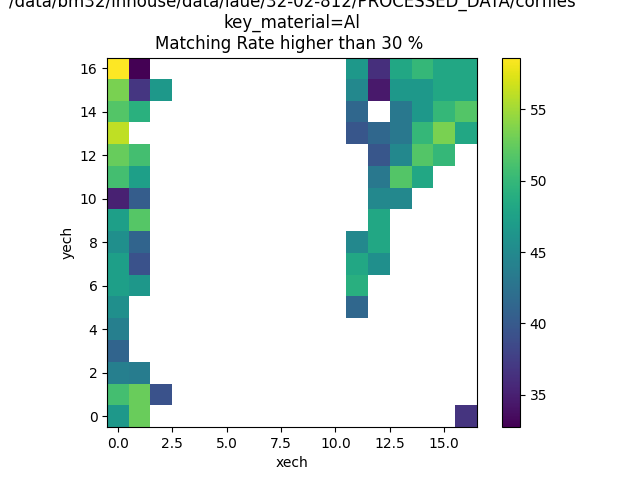

In [37]:
# using mask wrt mininmum number of matching rate (%)
MinMRthreshold = 30 # in %
cond_smallMR = MRindexedimages2D <= MinMRthreshold

# choose condition
cond = cond_smallMR #condG1  # cond_smallMR
#cond = condG1

fig3,ax3 = plt.subplots()
MRindexedimages2Dplot = copy.copy(MRindexedimages2D)
MRindexedimages2Dplot = ma.masked_where(cond, MRindexedimages2Dplot)
    
pp3= ax3.imshow(MRindexedimages2Dplot,origin='lower')
ax3.set_title(txt+f'\nMatching Rate higher than {MinMRthreshold} % ')
cb2 = plt.colorbar(pp3)

GT.format_getimageindex_imshow.__defaults__=(invmapdims,)
ax3.format_coord = GT.format_getimageindex_imshow
ax3.set_xlabel(motorfastaxis)
ax3.set_ylabel(motorslowaxis)

In [95]:
#ma.masked_array(Nbindexedimages2Dplot)
# True indexed, False non indexed
#maskindexed2D
# True, to be masked, False to be kept
#np.invert(maskindexed2D)

# COLLECT .fit files results 

**multiprocessing collection, read .fit files  and  plot results**

In [34]:
import LaueTools.fitfilereader  as fitreader
from LaueTools.fitfilereader import parsed_fitfile, parsed_fitfileseries
from LaueTools.LaueDataResultsPlots import (StrainMap, EulerAngles,EulerAngles2D,
                                            LatticeParamsMap, PlotNumberIndexedSpots,
                                           PlotMeanDevPixel, StrainMapHistogram)

def getimageindex_fromxyech(xech, yech, invmapdims, xech_stepsize=1., yech_stepsize = 1., startingindex = 0):
    """get imageindex from relative positions xech and yech  (mapdims =(xech dim, yech dim))
    
    invmapdims = dimensions (slow, fast)  axis
    """
    ii = int(xech/xech_stepsize)
    jj = int(yech/yech_stepsize)
    return startingindex + invmapdims[1]*jj+ii

def plotmask(mask, invmapdims, origin="lower", **kwargs):
    straincmap= mpl.colormaps['RdBl']
    straincmap.set_over('red')
    straincmap.set_bad('lightgray')
    straincmap.set_under('green')
    fig, ax = plt.subplots()
    ax.imshow(mask, origin=origin, cmap=straincmap, **kwargs)

# color map
mycmap = mpl.colormaps['PuRd']
mycmap.set_over('yellow')
mycmap.set_bad('black')


# colormap for strain
straincmap= mpl.colormaps['bwr'] #mpl.colormaps['seismic']  # seismic is ~ logarithm
straincmap.set_over('yellow')
straincmap.set_bad('lightgray')  # 'gray'
straincmap.set_under('green')


In [49]:
DATASET_EXAMPLE = 'Al'

if DATASET_EXAMPLE == 'Al':
    workdir='/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/fitfiles_Al'
if DATASET_EXAMPLE == 'Al/Al2Cu':
    workdir ='/data/bm32/inhouse/data/laue/32-02-812/PROCESSED_DATA/'
if DATASET_EXAMPLE == 'Zr':
    workdir ='/data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001'
    
#!ls -alptr {workdir}

In [49]:
print('COLLECTING and READING all .fit files in')

if DATASET_EXAMPLE == 'Al': 
    fitfilefolder = Path(workdir+'//'+'fitfiles_Al')
if DATASET_EXAMPLE=='Zr':
    
    fitfilefolder = Path(workdir+'//'+'fitfiles__1grainZr')
    fitfilefolder = Path(workdir+'//'+'fitfiles_notebook_Zr')
    fitfilefolder = Path(workdir+'//'+'fitfiles_1grains_veryfast_Zr_ref')
    fitfilefolder = Path(workdir+'//'+'fitfiles_1grains_veryfast_Zr_ref_3grains_veryfast_Cr_ref_3grains_veryfast_Cr_ref')
    fitfilefolder = Path(workdir+'//'+'fitfiles_1grains_highseek2_192cpus_Zr_ref')
    fitfilefolder = Path(workdir+'//'+'fitfiles_3grains_Zr')
    
if DATASET_EXAMPLE=='Al/Al2Cu':
    fitfilefolder = Path(workdir+'//'+'fitfiles_Al')
print(fitfilefolder)
print(mapdims)


ffs0 = parsed_fitfileseries(folderpath=fitfilefolder, nb_cols=mapdims[0], nb_rows=mapdims[1],
                            prefix = prefixfilename, suffix = '_g0.fit', use_multiprocessing = True)
ffs0.fitfilefolder = fitfilefolder

COLLECTING and READING all .fit files in
/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/fitfiles_Al
(51, 51)
Using 64 cpus.


Parsing progress:   0%|          | 0/2601 [00:00<?, ?it/s]

Done!


In [50]:
fitfilefolder

PosixPath('/data/visitor/utr20/bm32/20260310/PROCESSED_DATA/fitfiles_Al')

# VISUALIZE

In [51]:
# depending on scan   dmesh fastmotor .. ..  slowmotor .. ..
# if expID is not None:
#     if expId in ('a321216',) and DATASET_EXAMPLE=='Zr':
#         motorfastaxis = 'yech'
#         motorslowaxis = 'xech'
#     elif expId in ('blc15488') or DATASET_EXAMPLE=='Al/Al2Cu':
#         motorfastaxis = 'xech'
#         motorslowaxis = 'yech'

if DATASET_EXAMPLE == 'Al':
    xech_stepsize, yech_stepsize = 1., 1.
    motorfastaxis = 'yech'
    motorslowaxis = 'xech'
if DATASET_EXAMPLE=='Al/Al2Cu':
    motorfastaxis = 'xech'
    motorslowaxis = 'yech'
    xech_stepsize, yech_stepsize = 1., 1.
    #mapdims may be set there mapdims=(17, 17)
elif DATASET_EXAMPLE == 'Zr':
    xech_stepsize, yech_stepsize = 1., 1.
    motorfastaxis = 'yech'
    motorslowaxis = 'xech'

print('--- MAP raster scan properties: dimensions  and motors name and direction----')
print(f'`mapdims` (fast axis, slow axis)',mapdims)
print(f'motor                           ({motorfastaxis}, {motorslowaxis})')

--- MAP raster scan properties: dimensions  and motors name and direction----
`mapdims` (fast axis, slow axis) (51, 51)
motor                           (yech, xech)


## PLOT Nb of indexed spots (after refinement)

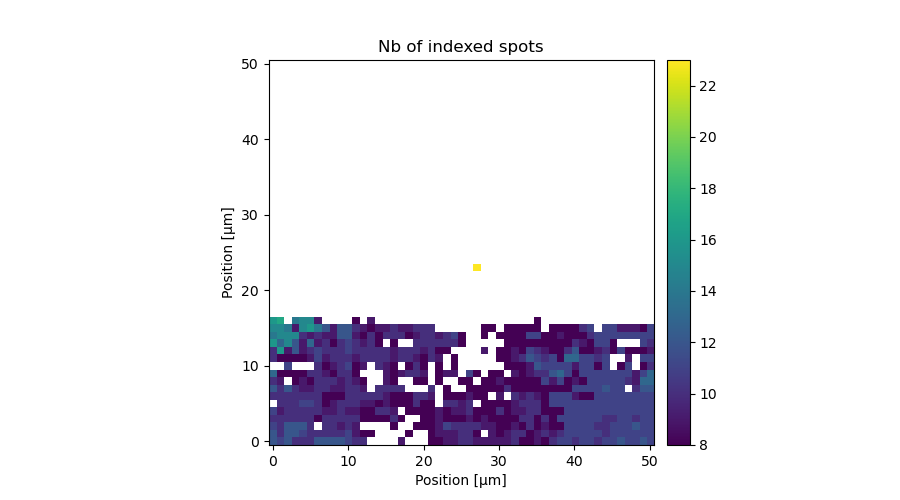

In [52]:
_, ax = PlotNumberIndexedSpots(indexed_fileseries = ffs0 , size = (9,5), origin='lower')
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

## PLOT Mean Pixel Deviation residue (after refinement)

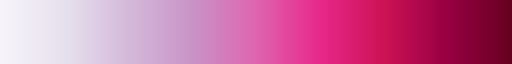

In [53]:
mycmap

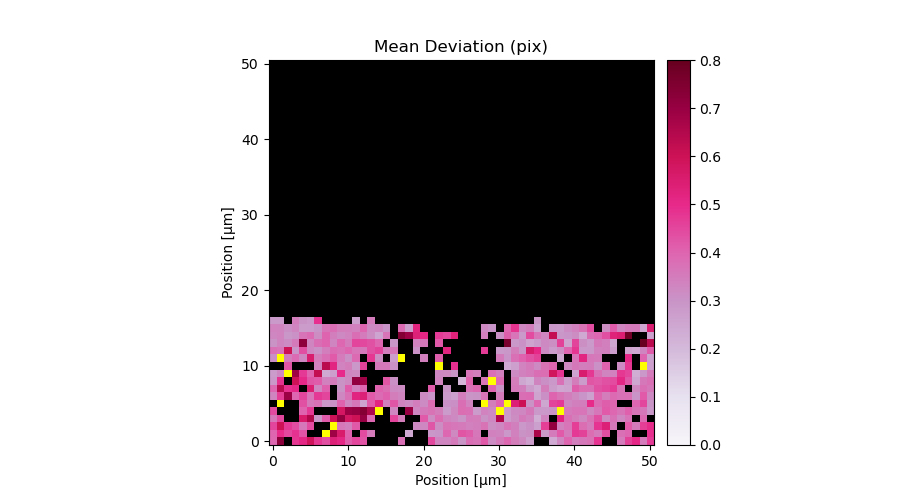

In [55]:
# FILTER & MASK
MinimumNbIndexedSpots = 0  # absolute nb of spots
LargestMeanPixelResidue = 1 # pixel unit
maxdisplayedMeanPixDev = .8  # in pixel units

# some masks
cond_lowNbindexed2D=ffs0.NumberOfIndexedSpots.reshape(invmapdims)<MinimumNbIndexedSpots
cond_largepixeldev = ffs0.MeanDevPixel.reshape(invmapdims)>LargestMeanPixelResidue
combinedconds = np.logical_or(cond_lowNbindexed2D,cond_largepixeldev)  # be careful it s OR !!!

#condgrain = np.invert(maskindexed2D)

# CHOOSE a MASK
#cond = condgrain
#cond = cond_smallMR
cond = combinedconds
#cond = None


_, ax = PlotMeanDevPixel(indexed_fileseries = ffs0 ,size = (9,5),
                         origin='lower', maskingcondition=cond,
                         norm= mpl.colors.Normalize(vmin=0,vmax=maxdisplayedMeanPixDev),
                        cmap=mycmap)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

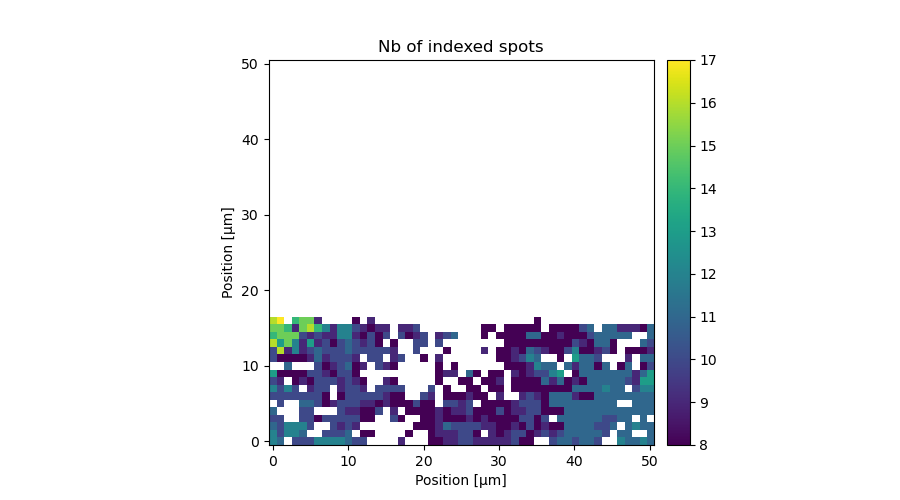

In [56]:
_, ax = PlotNumberIndexedSpots(indexed_fileseries = ffs0 , size = (9,5), origin='lower', maskingcondition=cond)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

In [56]:
#plotmask(condgrain, invmapdims, vmax=.9, vmin=0.1)

In [57]:
#plotmask(cond_smallMR, invmapdims, vmax=.9, vmin=0.1)

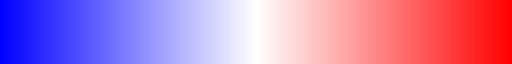

In [57]:
straincmap

## PLOT strain map

xechstep 1.0
yechstep 1.0
deviatoric strain xx shape (51, 51)


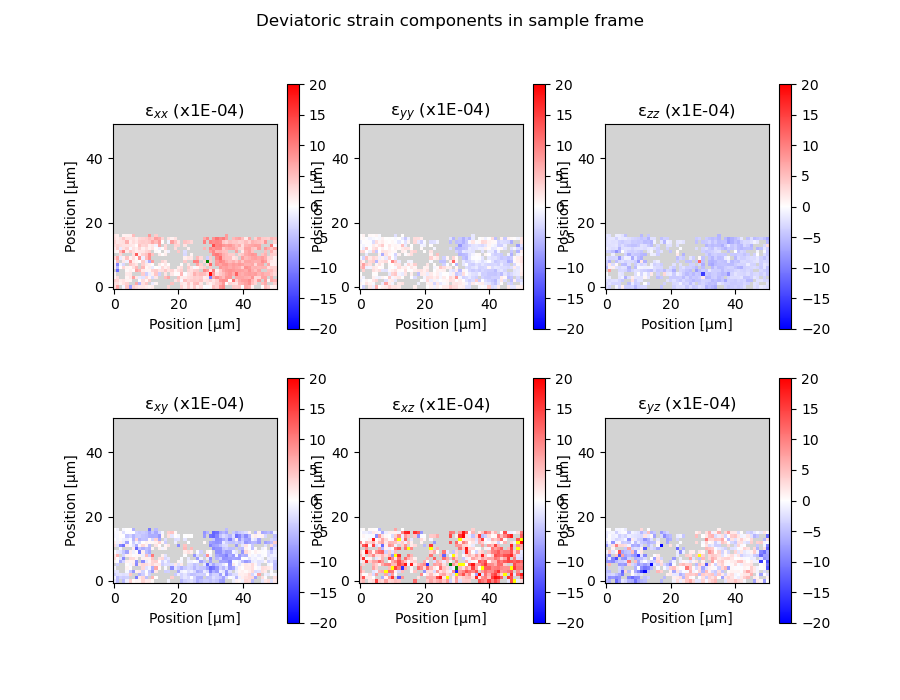

In [58]:
# visualisation parameters
maxamplitudestrain = 20  # in 10-4 units
strain_frame = 'sample' # 'sample' # 'crystal'
#cond = None#np.invert(maskindexed2D) #maskfromMR #None, combinedconds
#cond = condG1

fig, ax = StrainMap(xech = np.arange(mapdims[0])*xech_stepsize,
                    yech = np.arange(mapdims[1])*yech_stepsize,
                    indexed_fileseries = ffs0 , frame =strain_frame,
                    multiplier = 1e4,
                    scale = 'other', vmin=None, vmax=None,
                    norm= mpl.colors.Normalize(vmin=-maxamplitudestrain,vmax=maxamplitudestrain), # in 10-4 units
                    size = (9,7), cmap=straincmap,
                    maskingcondition=combinedconds)

#fig.tight_layout()
plt.show()

##  PLOT strain components level distributions

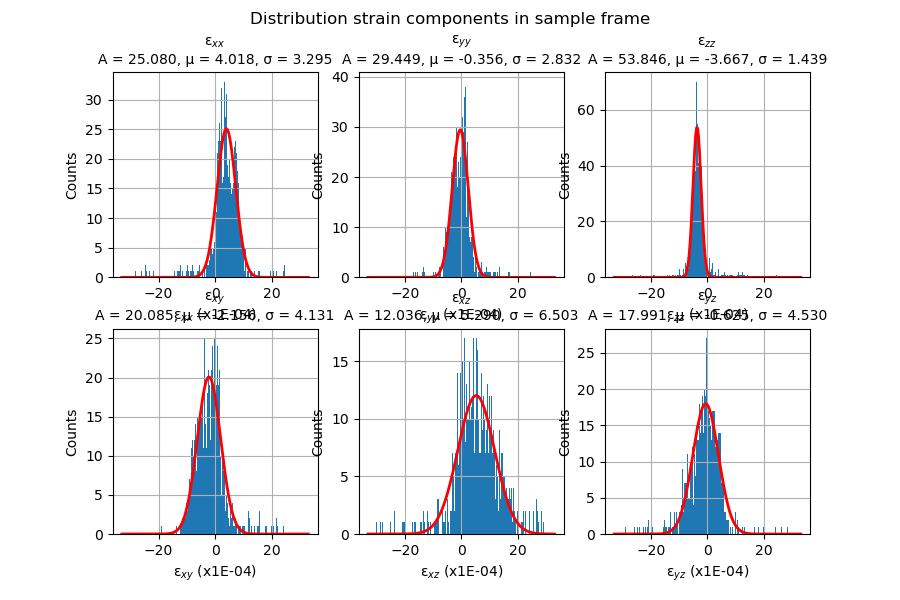

In [59]:
frame = 'sample' # crystal

multiplier = 1e4  # 1e4 for 10-4 unit for strain
fig, ax, fit_params = StrainMapHistogram(indexed_fileseries = ffs0,
                    multiplier = multiplier, maskingcondition=combinedconds.ravel(),#maskfromMR.ravel(),#combinedconds.ravel(),
                    size = (9,6),  frame=frame,
                    bins=np.linspace(-30,30,200), #400
                    fit=True)
[_ax.grid() for _ax in ax.ravel()]
plt.show()
#fig.tight_layout()

## STATISTICAL REPORT on Strain values

In [60]:
GT.printgreen(f'Deviatoric Strain distribution fit results:\ncomponent     mean      std')
print(f'         -- in {1./multiplier:e} units  in {frame} frame--')
if frame=='sample':
    listcomponent =['xx','yy','zz','xy','xz','yz']
elif frame=='crystal':
    listcomponent =['aa','bb','cc','ab','ac','bc']
#fit_params
for kk, comp in enumerate(listcomponent):
    amp, meanval, std = fit_params[kk]
    if kk == 3:
        print('-------')
    if meanval > 1:
        GT.printred(f'{comp}         {meanval:.3f}    {std:.3f}')
    elif meanval < -1:
        GT.pcolor(f'{comp}         {meanval:.3f}    {std:.3f}', 'b')
    else: print(f'{comp}         {meanval:.3f}    {std:.3f}')
    if kk == 5:
        print('-------')
fp = np.array(fit_params)
print(f'Largest absolute value: {np.amax(np.fabs(fp[:,1])):.2f}')
print(f'Largest tensile (positive) value: {np.amax(fp[:,1]):.2f}')
print(f'Largest compressive (negative) value: {np.amin(fp[:,1]):.2f}')

Deviatoric Strain distribution fit results:
component     mean      std
         -- in 1.000000e-04 units  in sample frame--
xx         4.018    3.295
yy         -0.356    2.832
zz         -3.667    1.439
-------
xy         -2.156    4.131
xz         5.290    6.503
yz         -0.625    4.530
-------
Largest absolute value: 5.29
Largest tensile (positive) value: 5.29
Largest compressive (negative) value: -3.67


In [61]:
#fit_params

## PLOT Lattice parameters map

xechstep 1.0
yechstep 1.0
alpha angle shape (51, 51)


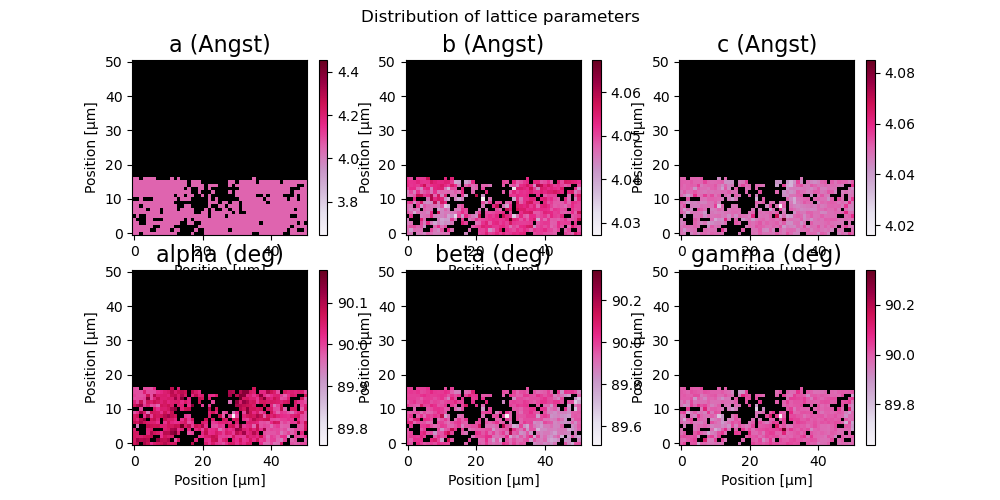

In [62]:
_,_ =LatticeParamsMap(xech = np.arange(mapdims[0])*xech_stepsize,
                    yech = np.arange(mapdims[1])*yech_stepsize,
                    indexed_fileseries = ffs0, # frame =strain_frame,
                    #multiplier = 1e4,
                    scale = 'default',
                    #norm= mpl.colors.Normalize(vmin=-maxamplitudestrain,vmax=maxamplitudestrain), # in 10-4 units
                    size = (10,5), cmap=mycmap,
                    maskingcondition=combinedconds)
plt.show()

## PLOT orientation map

### plot euler Angles

xechstep 1.0
yechstep 1.0


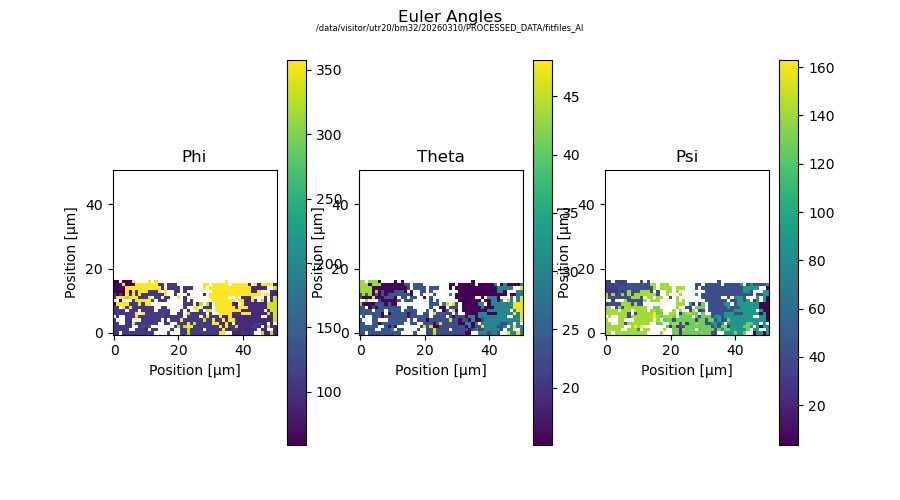

Statistics on Euler Angles -------------
For Phi: mean 189.64 deg     std 121.73 deg
For Theta: mean 24.05 deg     std 8.37 deg
For Psi: mean 88.68 deg     std 45.58 deg


In [63]:
phi, theta, psi = EulerAngles2D(xech = np.arange(mapdims[0])*xech_stepsize, yech = np.arange(mapdims[1])*yech_stepsize,
              indexed_fileseries = ffs0 , maskingcondition=combinedconds, #vlimits=((244,244.5),(44,46),(76, 76.5)),
              size = (9,5))
plt.show()

mphi = np.nanmean(phi)
mtheta = np.nanmean(theta)
mpsi = np.nanmean(psi)

stdphi = np.nanstd(phi)
stdtheta = np.nanstd(theta)
stdpsi = np.nanstd(psi)

print('Statistics on Euler Angles -------------')
for vm, vstd, q in zip([mphi, mtheta, mpsi],[stdphi, stdtheta, stdpsi],['Phi', 'Theta', 'Psi']):
    print(f'For {q}: mean {vm:.2f} deg     std {vstd:.2f} deg')

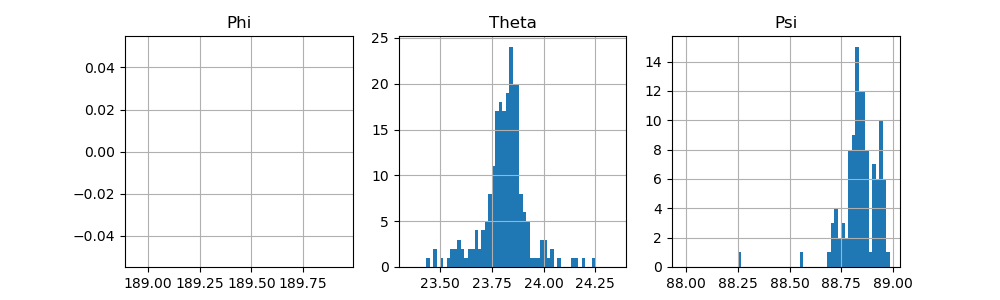

In [64]:
fighisteuler, axhisteuler = plt.subplots(1, 3, figsize=(10,3))
titles = ['Phi', 'Theta', 'Psi']

mphi = np.nanmean(phi)#244.2 #np.nanmean(phi)
mtheta = np.nanmean(theta)
mpsi = np.nanmean(psi)

nbbins= 60
deltaphi = 0.2
deltatheta = 0.2
deltapsi = 0.2

rangelist = [(quant-delta, quant-delta) for quant, delta in zip([mphi,mtheta,mpsi],[deltaphi, deltatheta, deltapsi])]

fighisteuler.subplots_adjust(hspace = 0.25, wspace = 0.2)
for kk, (axis, data, tit) in enumerate(zip(axhisteuler, (phi, theta, psi), titles)):
    counts, bins, patches = axis.hist(data.ravel(), range=rangelist[kk], bins=nbbins)
    axis.set_title(tit)
    axis.grid()
    

In [65]:
i_image=getimageindex_fromxyech(6,0, invmapdims)  #fast axis, slow axis, invmapdims = (slow, fast)
i_image

6

In [66]:
# sample location by index along x and y 
image_ix, image_iy = 6, 0
i_image=getimageindex_fromxyech(image_ix, image_iy, invmapdims)  #fast axis, slow axis, invmapdims = (slow, fast)
print(f'For image #={i_image}, Orientation Matrix UB:\n',ffs0.UB[i_image].tolist())

ffile = parsed_fitfile(os.path.join(fitfilefolder,f'{prefixfilename}%04d_g0.fit'%i_image), verbose=0)
ffile.UB, ffile.NumberOfIndexedSpots, ffile.MeanDevPixel

For image #=6, Orientation Matrix UB:
 [[0.774751579, -0.579422413, -0.255391021], [0.500151033, 0.807583008, -0.313234728], [0.386953171, 0.115738043, 0.914742032]]


(array([[ 0.774751579, -0.579422413, -0.255391021],
        [ 0.500151033,  0.807583008, -0.313234728],
        [ 0.386953171,  0.115738043,  0.914742032]]),
 12,
 0.473)

### PLOT ~ inverse pole figure map

0.0 1.4061073404676363


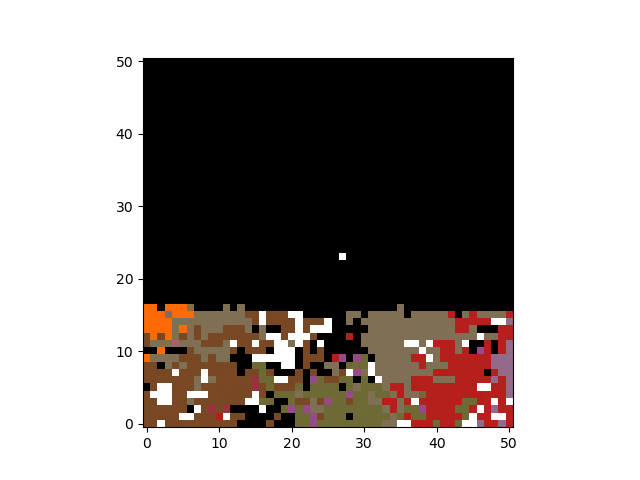

In [67]:
import LaueTools.orientations as ORI

maskingcondition = combinedconds
#UBs2Dmap = ffs0.UB.reshape((mapdims[0],mapdims[1],3,3))
rgbs =[]
for _k  in range(len(ffs0.UB)):
    #print('_k',_k)
    ub = ffs0.UB[_k]
    if np.isnan(ub[0][0]):
        rgbs.append([0,0,0])
    else:
        rgbs.append(ORI.myRGB_3(ub))
rgbs = np.array(rgbs)

rgbs=rgbs.reshape((mapdims[1],mapdims[0],3))
rgbs = np.where(np.logical_not(maskingcondition[..., None]), rgbs, np.nan)

vmin = np.nanmin(rgbs)
vmax = np.nanmax(rgbs)
print(vmin,vmax)
stretched = np.clip((rgbs - vmin) / (vmax - vmin), 0, 1)
# plot
fig, ax = plt.subplots()
ax.imshow(stretched, origin='lower')
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

In [68]:
# for the same structure
B0matrix = ffs0.B0[0]
B0matrix
tensorcomponent_ij_list =[(0,0),(0,1),(0,2),
                          (1,0),(1,1),(1,2),
                          (2,0),(2,1),(2,2)]
tensortitles = ['100 // x','100 // y','100 // z',
                '010 // x','010 // y','010 // z',
                '001 // x','001 // y','001 // z']
tensortitles2 = ['a* // x','a* // y','a* // z',
                'b* // x','b* // y','b* // z',
                'c* // x','c* // y','c* // z']
cmp_axes = np.array([[1,0,0],[1,0,0],[1,0,0],[0,1,0],[0,1,0],[0,1,0],[0,0,1],[0,0,1],[0,0,1]])
proj_axes = np.array([[1,0,0],[0,1,0],[0,0,1],[1,0,0],[0,1,0],[0,0,1],[1,0,0],[0,1,0],[0,0,1]])

samplerot = GT.matRot([0,1,0],-40)

cosvals = [[] for _ in range(len((tensorcomponent_ij_list)))]
for _k  in range(len(ffs0.UB)):
    #print('_k',_k)
    ubb0 = np.dot(ffs0.UB[_k],B0matrix)
    for cmp, tensorcomponent_ij in enumerate(tensorcomponent_ij_list):
        j,i =tensorcomponent_ij
        if np.isnan(ubb0[i][j]):
            cosval = 1.  # default
        else:
            qdir = np.dot(ubb0, cmp_axes[cmp])
            nqdir = np.linalg.norm(qdir)
            #print('astar_dir',astar_dir)
            cosval = np.abs(np.dot(qdir/nqdir, samplerot.dot(proj_axes[cmp])))
        
        cosvals[cmp].append(cosval)
tab_cmps = []
for kk in range(len(tensorcomponent_ij_list)):
    tab_cmps.append(np.array(cosvals[kk]).reshape(invmapdims))

In [69]:
# ix=0
# ubb0 = np.dot(ffs0.UB[ix],B0matrix)
# qdir = np.dot(ubb0, cmp_axes[2])
# nqdir = np.linalg.norm(qdir)
# cval = np.abs(np.dot(qdir/nqdir, samplerot.dot(proj_axes[2])))
# qdir/nqdir, zsample, cval

Text(0, 0.5, 'xech')

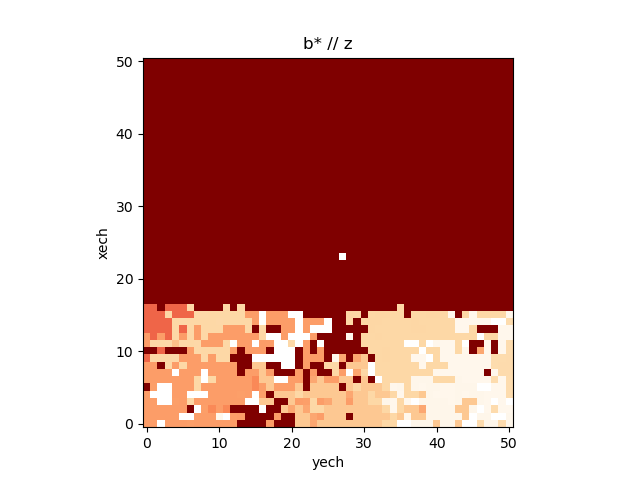

In [70]:
i_cmp = 5  # component
fig, ax = plt.subplots()
datmap = tab_cmps[i_cmp]

datmap = np.where(np.logical_not(maskingcondition), datmap, np.nan)
ax.imshow(datmap, cmap='OrRd', origin='lower')
ax.set_title(tensortitles2[i_cmp])
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)
ax.set_xlabel(motorfastaxis)
ax.set_ylabel(motorslowaxis)

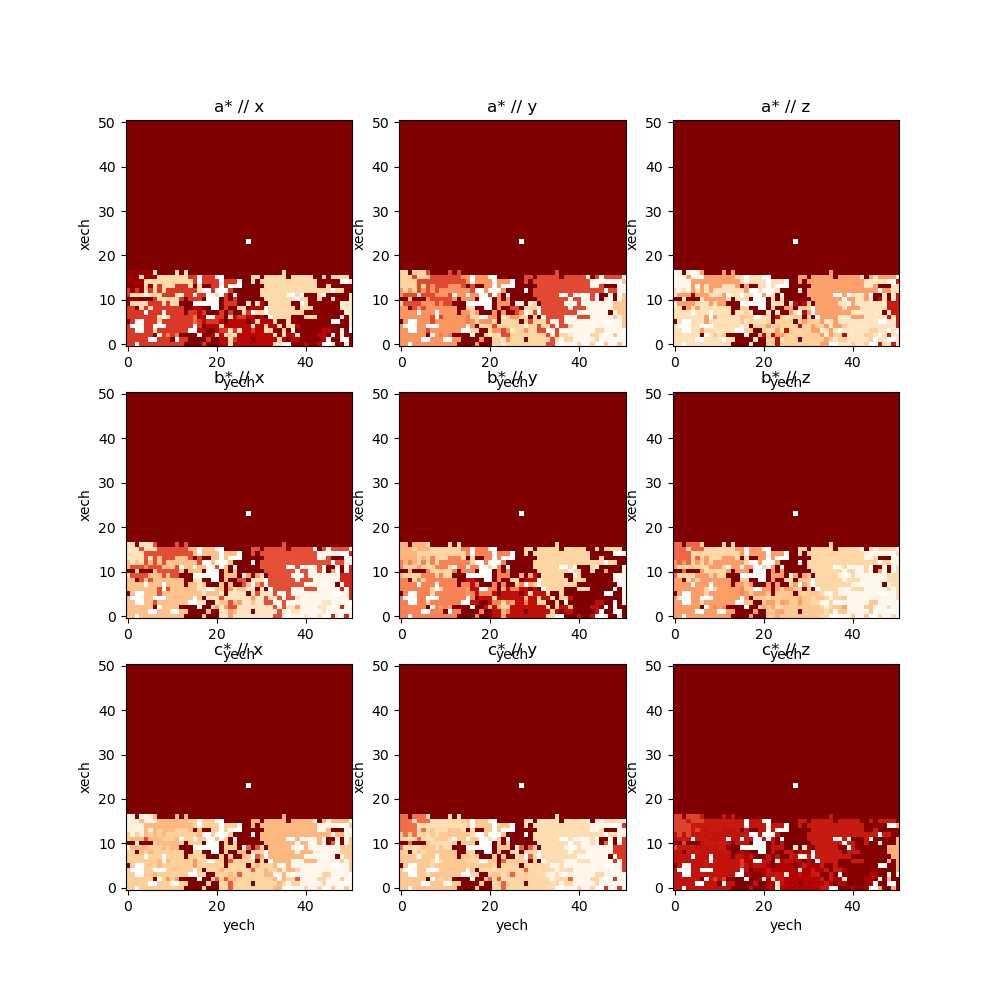

In [71]:
fig, ax = plt.subplots(3,3, figsize=(10, 10))
for axidx, data, _title in zip(np.ndindex(ax.shape), tab_cmps, tensortitles2):
    #ax[axidx].imshow(data, cmap='OrRd', origin='lower')
    datmap = np.where(np.logical_not(maskingcondition), data, np.nan)
    #ax[axidx].imshow(np.abs(data), cmap='seismic', origin='lower')
    ax[axidx].imshow(np.abs(datmap), cmap='OrRd', origin='lower')
    ax[axidx].set_title(_title)
    ax[axidx].format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)
    ax[axidx].set_xlabel(motorfastaxis)
    ax[axidx].set_ylabel(motorslowaxis)
plt.show()

## (TODO) PLOT KAM local misorientation

In [72]:
# TODO compute kernel average Map

## PLOT MISORIENTATION angle (deg)

In [73]:
# ref UB matrice
i_ref = 0
UB0 = ffs0.UB[i_ref]
refUB0 = np.linalg.qr(UB0)[0]

print('UB ref',UB0.tolist())

AngleDev = []
for ii in range(mapdims[0]*mapdims[1]):
    repUB = np.linalg.qr(ffs0.UB[ii])[0]
    AngleDev.append(GT.getRotationAngleFrom2Matrices(refUB0, repUB))


AngleDev = np.array(AngleDev)
#AngleDev

UB ref [[0.775542141, -0.579061517, -0.254166603], [0.499840411, 0.807825035, -0.313434557], [0.386499058, 0.117221147, 0.914796273]]


/tmp/ipykernel_4171200/1672929401.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


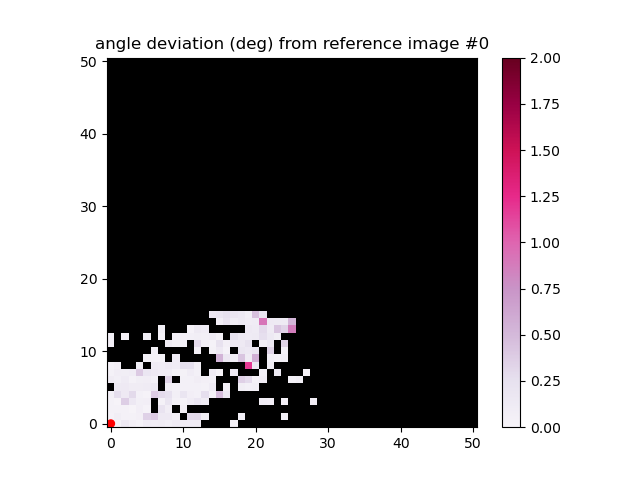

In [74]:
# color map
mycmapori = mpl.colormaps['PuRd']
mycmapori.set_over('black')
mycmapori.set_bad('black')

fig, ax = plt.subplots()
im = ax.imshow(AngleDev.reshape(invmapdims), vmin=0, vmax=2, cmap = mycmapori, origin='lower')
ax.set_title(f'angle deviation (deg) from reference image #{i_ref}')
xref, yref = i_ref%mapdims[0], i_ref // mapdims[0]
circle1 = plt.Circle((xref, yref), 0.5, color='r')
plt.colorbar(im)

ax.add_patch(circle1)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

## SOME plots of LAUE patterns

In [ ]:
if DATASET_EXAMPLE = 'Zn':
    imageindex_1 = 888
    imageindex_2 = 1377
    imageindex_3 = 714
    
    filename1 = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex_1)
    filename2 = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex_2)
    filename3 = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex_3)
    from LaueTools.LaueDataResultsPlots import PlotPeakPos
    ff, aa = PlotPeakPos(filename1, label=f'#{imageindex_1}',frame='angles',showindex=True, marker='*',
                     cmap = plt.cm.inferno, alpha=0.9)
    aa.grid(True)
    
    PlotPeakPos(filename2, label=f'image #{imageindex_2}',frame='angles',figax=(ff, aa), facecolors="none", edgecolor='r',alpha=0.7)
    
    PlotPeakPos(filename3, label=f'image #{imageindex_3}',frame='angles',figax=(ff, aa), facecolors="none", marker='h', edgecolor='k',alpha=0.7)

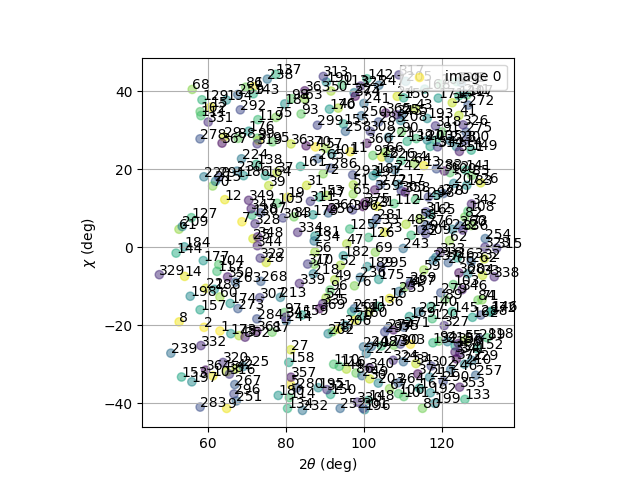

In [117]:
imageindex_1 = 0

filename1 = os.path.join(corfilefolder,f'{prefixfilename}%04d.cor'%imageindex_1)

from LaueTools.LaueDataResultsPlots import PlotPeakPos
ff, aa = PlotPeakPos(filename1, frame='angles',showindex=True,
                     label=f'image {imageindex_1}',alpha=0.5)
aa.grid(True)

In [ ]:
# create N different strcuture with a fixed orientation matrix

c0 = 4.85
mymaterials = {}
for kk in range(10):
    mymaterials['Zn%d'%kk]= ['Zn%d'%kk, [2.6649, 2.6649, c0+0.03*kk, 90, 90, 120], 'wurtzite']
    
mymaterials = {}
a0,b0,c0,alp0, bet0, gam0 = DictLT.dict_Materials['Zn'][1]
N = 20
deltal= np.random.uniform(-.1,.1,size=(N,2))
deltaangles = np.random.uniform(-.1,.1,size=(N,3))
for kk, deltas in enumerate(zip(deltal,deltaangles)):
    da=0
    db, dc = deltas[0]
    dalp, dbet, dgam = deltas[1]
    mymaterials['Zntest%d'%kk]= ['Zntest%d'%kk, [a0+da, b0+db, c0+dc, 90+dalp, 90+dbet, 120+dgam], 'wurtzite']
    
print('\n-------- mymaterials  dict --------------')
print(mymaterials)

In [ ]:
# General parameters indexation
e_min = 5   # [keV]
e_max = 18  # [keV]  # for indexation only ?? (how to refine with emax larger?)
### -----------arguments of IndexSpotsSet() ------------ ###

# ------------  GuessedUBMatrix ---------------
#Since previousResults is limited to single phase or material.Even better we can test a 

# Index refine parameters
dict_indexrefine = {'AngleTolLUT': 0.2,   # Tolerance angle [deg] to recognise angles in the Angular LUT Database
                    'nlutmax': 5,         # Maximum miller index in the Angular LUT Database
                    # Angular tolerance list for auto links between exp. - theo. spots
                    'list matching tol angles': [1,0.5,0.2,0.1,0.1], 
                    # spots set A:  [0,2,58,34] CAUTION max(A) < NBMAXPROBED
                    'central spots indices': [0,1,2],   
                    #number of most intense spot candidate to have a recognisable distance
                    'NBMAXPROBED': 5, # spots set B alias of [0, ..., NBMAXPROBED-1]
                    'MATCHINGRATE_ANGLE_TOL': 0.5,
                    'MinimumMatchingRate': 0,
                    'MinimumNumberMatches': 20,
                    'UseIntensityWeights': False,
                    'nbSpotsToIndex': 10000, # during refinement max number of pairs exp.-theo. spots
                    'CheckOrientation': None, # os.path.join(working_dir,'UBmat.ubs'),
                    'MATCHINGRATE_THRESHOLD_IAL': 2,
                    'GuessedUBMatrix': previousResults
                    }

# list of minimum matching rates that accept to perform the next refinement step (with less tolerance angle)
# Last term is the final minimum matching rate (in percent) to accept the final refinement.
MatchingRate_List = [2,2,2,2,2,2] 
# len(MatchingRate_List) > len('list matching tol angles')

In [ ]:
imageindex = 547
pathfilecor = os.path.join(corfilefolder,'img_%04d.cor'%imageindex)


t0 = time.time()
# (Re)Initialize object spotsset
UBsol = np.array([[-0.946190704006459, -0.165042674567985,  0.280650321594703],
       [ 0.32573740376703 , -0.402236471801761,  0.850366386984638],
       [-0.027936014406621,  0.900811005080669,  0.431842883341892]])
previousResults = (1,[UBsol],0,0)
res=[]
for kk in range(N):
    # missing info from the dictionary filled manually
    key_material = 'Zntest%d'%kk
    
    dataset = ISS.spotsset()

    # Init the dataset with laue spots of .cor file
    dataset.importdatafromfile(pathfilecor)
    dataset.key_material = key_material
    dataset.emin = e_min
    dataset.emax = e_max
    
    dataset.inhibitindexing = True

    # index the current dataset
    dataset.IndexSpotsSet(None,key_material,e_min,e_max,dict_indexrefine,None,
                                  use_file=0, # if 1 , reinit dataset and first argument must be a path to .cor file
                                  IMM=False,
                                  n_LUT = dict_indexrefine['nlutmax'],
                                  LUT = None,
                                  angletol_list = dict_indexrefine['list matching tol angles'],
                                  nbGrainstoFind = 1, 
                                  previousResults = previousResults,
                                  dirnameout_fitfile = fitfilefolder,
                                  corfilename = pathfilecor,
                                  verbose = 0,
                                  MatchingRate_List = MatchingRate_List,
                                dictmaterials = mymaterials,
                                 choose_UB_MinEulerepresentative=False)
    
    pixelresidues = dataset.pixelresidues
    if pixelresidues is None:
        meanpixel= -1
        pixelresidues = []
    else:
        meanpixdev = np.mean(pixelresidues)

    print(f'\n---- Resulst of indexing image #{imageindex} ----')
    print("initial nb of spots",dataset.nbspots)
    print("dict of UB matrix found",dataset.dict_grain_matrix)
    print('dict of nb of indexed spots and matching rate (%):',dataset.dict_grain_matching_rate)
    print('[FOR CHECK] nb of spots for refinements',len(pixelresidues))
    print('Mean pixel residue',meanpixdev) 
    print('elapsed time %.2f sec  with internal multiprocessing of {nbmaxcpus} cpus'%(time.time()-t0))
    if dataset.dict_grain_matrix is {} or any([v is None for v in dataset.dict_grain_matrix.values()]):
        print('Nothing found ')
    res.append([dataset.dict_grain_devstrain, dataset.dict_grain_latticeparameters, dataset.key_material,
                dataset.dict_grain_matching_rate,
                len(pixelresidues), meanpixdev ])
    

In [ ]:
afinal = []
bfinal = []
cfinal = []
alphafinal = []
betafinal = []
gammafinal = []

latparamsfinal = []
Nindexed_MR = []
Pixdev = []
minPixdev = 100
maxNindexed = 0
for el in res:
    grain_ix = 0
    rr = el[1][grain_ix]
    nbindexed_mr = el[3][grain_ix]
    # by default it s grain 0
    pixdev = el[-1]
    if pixdev<minPixdev:
        minPixdev = pixdev
    if nbindexed_mr[0]>maxNindexed:
        maxNindexed = nbindexed_mr[0]
    
    if rr is not None:
        latparamsfinal.append(rr)
        Nindexed_MR.append(nbindexed_mr)
        Pixdev.append(pixdev)
    
latparamsfinal = np.array(latparamsfinal)
Nindexed_MR = np.array(Nindexed_MR)
Pixdev = np.array(Pixdev)
print('nb of refined solutions', len(latparamsfinal))
print('mean results', np.mean(latparamsfinal, axis=0))
print('std results', np.round(np.std(latparamsfinal, axis=0), decimals=6))
print('max mb indexed spots:',maxNindexed)
print('min pix dev:',minPixdev)
#latparamsfinal,Nindexed_MR

In [ ]:
# select only solutions with the SAME Nb of indexed spots
latparamsfinal_select = []
for kk,el in enumerate(latparamsfinal):
    if Nindexed_MR[kk][0]==maxNindexed:
        latparamsfinal_select.append(el)
    
latparamsfinal_select=np.array(latparamsfinal_select)

In [ ]:
print('on selected refined solutions with %d indexed spots'%maxNindexed)
print('nb of refined solutions', len(latparamsfinal_select))
print('Statistical results\n             a,         b,         c,     alpha,   beta,   gamma')
GT.printgreen(f'mean       {np.round(np.mean(latparamsfinal_select, axis=0), decimals=4)}')
GT.printgreen(f'std results {np.round(np.std(latparamsfinal_select, axis=0), decimals=7)}')
print('max mb indexed spots:',maxNindexed)